
Starting Nested Cross-Validation for XGBoost...

Fold 1...
Original class distribution in training fold: Counter({0: 41448, 1: 4888, 2: 2534, 3: 1240})


c:\Users\Guest Hoefkestraat\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\core.py:158: UserWarning: [12:25:59] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0ed59c031377d09b8-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


  Fold 1 Accuracy: 0.9364623243933589
  Fold 1 F1 Score: 0.937434159202906
  Fold 1 ROC AUC Score: 0.8459952100207948

Fold 2...
Original class distribution in training fold: Counter({0: 41448, 1: 4888, 2: 2533, 3: 1241})


c:\Users\Guest Hoefkestraat\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\core.py:158: UserWarning: [12:28:54] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0ed59c031377d09b8-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


  Fold 2 Accuracy: 0.9370210727969349
  Fold 2 F1 Score: 0.9378378045276434
  Fold 2 ROC AUC Score: 0.8446763704253591

Fold 3...
Original class distribution in training fold: Counter({0: 41448, 1: 4888, 2: 2533, 3: 1241})


...

  Fold 4 Accuracy: 0.938213458928714
  Fold 4 F1 Score: 0.938840119328181
  Fold 4 ROC AUC Score: 0.8480813934592994

Fold 5...
Original class distribution in training fold: Counter({0: 41448, 1: 4888, 2: 2534, 3: 1241})


c:\Users\Guest Hoefkestraat\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\core.py:158: UserWarning: [12:37:46] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0ed59c031377d09b8-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


  Fold 5 Accuracy: 0.9362975971900694
  Fold 5 F1 Score: 0.9376991263011797
  Fold 5 ROC AUC Score: 0.8508454426180636


c:\Users\Guest Hoefkestraat\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\core.py:158: UserWarning: [12:41:23] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0ed59c031377d09b8-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



XGBoost Best Parameters (pipeline with undersampling): {'model__subsample': 0.7, 'model__n_estimators': 200, 'model__max_depth': 7, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.7}
XGBoost Accuracy on Test Set: 0.9383780332056194
XGBoost F1 Score on Test Set: 0.9391172016593439
XGBoost ROC AUC Score on Test Set: 0.9842412208418562
XGBoost Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     12953
           1       0.83      0.75      0.79      1527
           2       0.63      0.38      0.48       792
           3       0.36      0.74      0.48       388

    accuracy                           0.94     15660
   macro avg       0.70      0.72      0.69     15660
weighted avg       0.95      0.94      0.94     15660



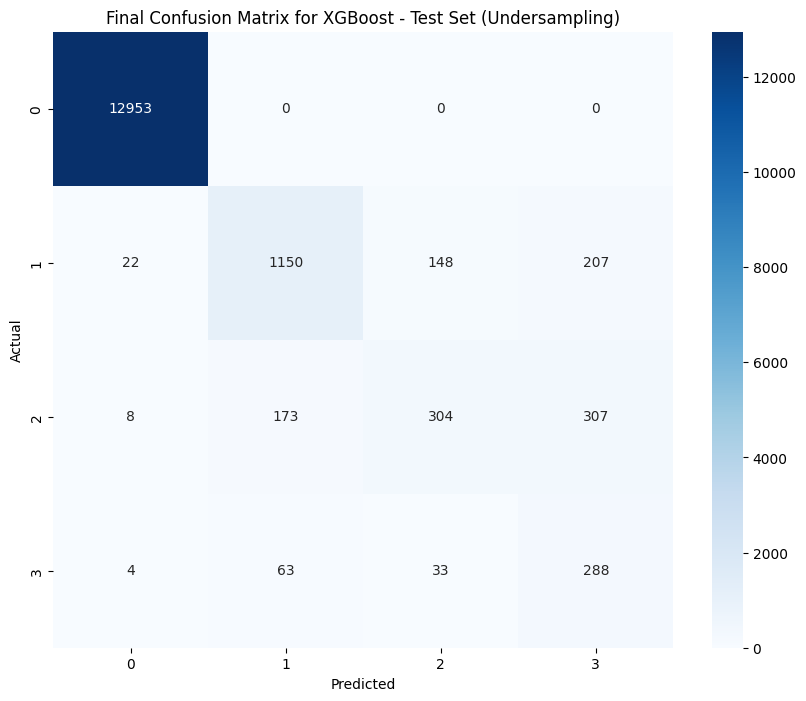

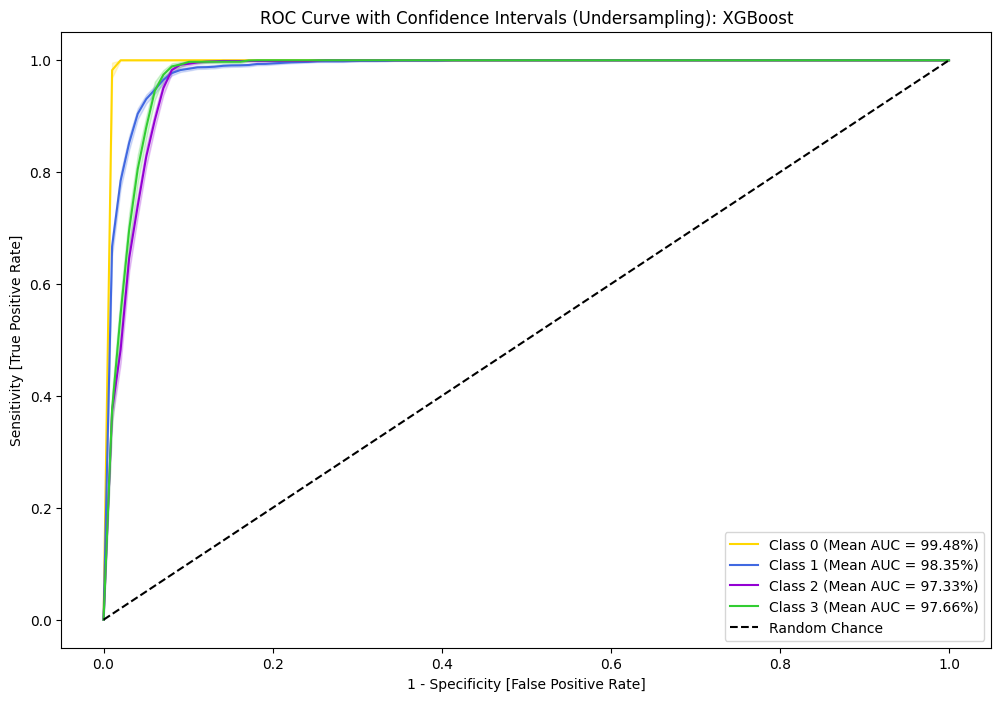


XGBoost train and test predictions have been saved separately.


In [ ]:
import pandas as pd
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import auc, accuracy_score, f1_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from imblearn.pipeline import Pipeline  # Import the pipeline from imbalanced-learn
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import joblib
from imblearn.over_sampling import SMOTE  # Import SMOTE


# Load data
train_resampled_set = pd.read_csv('train_set.csv')
test_set = pd.read_csv('test_set.csv')

X_train = train_resampled_set.drop(columns=['N_claims_year', 'ID'])
y_train = train_resampled_set['N_claims_year']
X_test = test_set.drop(columns=['N_claims_year', 'ID'])
y_test = test_set['N_claims_year']

# Define parameter grids for each model
param_grid_xgb = {
    'model__n_estimators': [50, 100, 200],
    'model__learning_rate': [0.01, 0.1, 0.2],
    'model__max_depth': [3, 5, 7],
    'model__subsample': [0.7, 0.8, 1.0],
    'model__colsample_bytree': [0.7, 0.8, 1.0]
}

# Updated function with pipeline for undersampling
def nested_cv_model(model, param_grid, model_name, X_train, y_train, X_test, y_test):
    print(f"\nStarting Nested Cross-Validation for {model_name}...")

    # Define the pipeline with undersampling and the model
    pipeline = Pipeline([
        ('over', SMOTE(random_state=42)),  # Use SMOTE here
        ('model', model)
    ])

    # Inner cross-validation for hyperparameter tuning using the pipeline
    inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    search = RandomizedSearchCV(
        pipeline,
        param_distributions=param_grid,
        n_iter=10,
        scoring={'accuracy': 'accuracy', 'f1_weighted': 'f1_weighted'},
        refit='accuracy',
        cv=inner_cv,
        n_jobs=-1,
        random_state=42
    )

    # Outer cross-validation for model evaluation
    outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # Collect scores for each fold
    fold_results = []
    for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X_train, y_train), start=1):
        print(f"\nFold {fold}...")

        # Split data for this fold
        X_train_fold, X_test_fold = X_train.iloc[train_idx], X_train.iloc[test_idx]
        y_train_fold, y_test_fold = y_train.iloc[train_idx], y_train.iloc[test_idx]

        # Print class distribution in the original outer fold's training subset before resampling
        print("Original class distribution in training fold:", Counter(y_train_fold))

        # Inner cross-validation with hyperparameter tuning and resampling handled by the pipeline
        search.fit(X_train_fold, y_train_fold)

        # Evaluate on the outer test fold
        y_pred_fold = search.predict(X_test_fold)
        accuracy_fold = accuracy_score(y_test_fold, y_pred_fold)
        f1_fold = f1_score(y_test_fold, y_pred_fold, average='weighted')
        roc_auc_fold = roc_auc_score(pd.get_dummies(y_test_fold), pd.get_dummies(y_pred_fold), average='macro', multi_class='ovr')

        # Print fold results
        print(f"  Fold {fold} Accuracy: {accuracy_fold}")
        print(f"  Fold {fold} F1 Score: {f1_fold}")
        print(f"  Fold {fold} ROC AUC Score: {roc_auc_fold}")

        fold_results.append((fold, accuracy_fold, f1_fold, roc_auc_fold))

        # Plot confusion matrix for each fold
        conf_matrix = confusion_matrix(y_test_fold, y_pred_fold)
        plt.figure(figsize=(8, 6))
        sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
        plt.title(f"Confusion Matrix for {model_name} - Fold {fold}")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.savefig(f"{model_name}_conf_matrix_fold_{fold}.png")
        plt.close()

    # Train the best model on the entire training set
    search.fit(X_train, y_train)
    best_model = search.best_estimator_

    # Predictions on training and test sets
    y_pred_train = best_model.predict(X_train)
    y_pred_test = best_model.predict(X_test)
    y_pred_probabilities = best_model.predict_proba(X_test)

    # Evaluation metrics on test set
    accuracy = accuracy_score(y_test, y_pred_test)
    f1 = f1_score(y_test, y_pred_test, average='weighted')
    roc_auc = roc_auc_score(pd.get_dummies(y_test), y_pred_probabilities, average='macro', multi_class='ovr')

    class_report = classification_report(y_test, y_pred_test)
    conf_matrix = confusion_matrix(y_test, y_pred_test)

    # Display results
    print(f"\n{model_name} Best Parameters (pipeline with undersampling): {search.best_params_}")
    print(f"{model_name} Accuracy on Test Set: {accuracy}")
    print(f"{model_name} F1 Score on Test Set: {f1}")
    print(f"{model_name} ROC AUC Score on Test Set: {roc_auc}")
    print(f"{model_name} Classification Report:\n{class_report}")

    # Plot final confusion matrix for the test set
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
    plt.title(f"Final Confusion Matrix for {model_name} - Test Set (Undersampling)")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.savefig(f"{model_name}_final_conf_matrix.png")
    plt.show()

    # Updated ROC curve plotting with bootstrapped confidence intervals
    plt.figure(figsize=(12, 8))
    colors = ['gold', 'royalblue', 'darkviolet', 'limegreen']

    y_test_dummies = pd.get_dummies(y_test)
    bootstraps = 1000  # Number of bootstrap samples
    mean_fpr = np.linspace(0, 1, 100)

    for i, class_label in enumerate(np.unique(y_test)):
        tprs = []

        for _ in range(bootstraps):
            indices = np.random.randint(0, len(y_test), len(y_test))
            y_true_bootstrap = y_test_dummies.iloc[indices, i]
            y_pred_bootstrap = y_pred_probabilities[indices, i]
            fpr, tpr, _ = roc_curve(y_true_bootstrap, y_pred_bootstrap)
            tpr_interp = np.interp(mean_fpr, fpr, tpr)
            tpr_interp[0] = 0.0
            tprs.append(tpr_interp)

        mean_tpr = np.mean(tprs, axis=0)
        mean_tpr[-1] = 1.0
        mean_auc = auc(mean_fpr, mean_tpr)
        std_tpr = np.std(tprs, axis=0)

        plt.plot(mean_fpr, mean_tpr, color=colors[i % len(colors)], label=f'Class {class_label} (Mean AUC = {mean_auc:.2%})')
        plt.fill_between(mean_fpr, mean_tpr - std_tpr, mean_tpr + std_tpr, color=colors[i % len(colors)], alpha=0.2)

    plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
    plt.title(f"ROC Curve with Confidence Intervals (Undersampling): {model_name}")
    plt.xlabel("1 - Specificity [False Positive Rate]")
    plt.ylabel("Sensitivity [True Positive Rate]")
    plt.legend(loc='lower right')
    plt.savefig(f"{model_name}_roc_curve_with_ci_undersampling.png")
    plt.show()

    # Export separate CSVs for train and test set predictions
    train_df = X_train.copy()
    train_df['y_true_train'] = y_train
    train_df['y_pred_train'] = y_pred_train

    test_df = X_test.copy()
    test_df['y_true_test'] = y_test
    test_df['y_pred_test'] = y_pred_test

    train_df.to_csv(f"{model_name.lower().replace(' ', '_')}_train_undersampling_pipe.csv", index=False)
    test_df.to_csv(f"{model_name.lower().replace(' ', '_')}_test_undersampling_pipe.csv", index=False)
    print(f"\n{model_name} train and test predictions have been saved separately.")

    # Save the model
    joblib.dump(best_model, f"{model_name}_best_model.joblib")

    return fold_results, best_model

# 18 mins Run the nested CV with the XGBoost model as an example
fold_results_xgb, best_model_xgb = nested_cv_model(XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42), param_grid_xgb, 'XGBoost', X_train, y_train, X_test, y_test)



Starting Nested Cross-Validation for XGBoost...

Fold 1...
Original class distribution in training fold: Counter({0: 41448, 1: 4888, 2: 2534, 3: 1240})


c:\Users\Prapatsorn\miniconda3\Lib\site-packages\sklearn\model_selection\_search.py:307: UserWarning: The total space of parameters 1 is smaller than n_iter=10. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
c:\Users\Prapatsorn\miniconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [22:25:18] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


  Fold 1 Accuracy: 0.9364623243933589
  Fold 1 F1 Score: 0.9374341592029062
  Fold 1 ROC AUC Score: 0.8459952100207948

Fold 2...
Original class distribution in training fold: Counter({0: 41448, 1: 4888, 2: 2533, 3: 1241})


c:\Users\Prapatsorn\miniconda3\Lib\site-packages\sklearn\model_selection\_search.py:307: UserWarning: The total space of parameters 1 is smaller than n_iter=10. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
c:\Users\Prapatsorn\miniconda3\Lib\site-packages\sklearn\model_selection\_validation.py:425: FitFailedWarning: 
2 fits failed out of a total of 5.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
2 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Prapatsorn\miniconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 729, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\Prapatsorn\miniconda3\Lib\site-packages\s

  Fold 2 Accuracy: 0.9370210727969349
  Fold 2 F1 Score: 0.9378378045276434
  Fold 2 ROC AUC Score: 0.8446763704253591

Fold 3...
Original class distribution in training fold: Counter({0: 41448, 1: 4888, 2: 2533, 3: 1241})


...

  Fold 4 Accuracy: 0.938213458928714
  Fold 4 F1 Score: 0.938840119328181
  Fold 4 ROC AUC Score: 0.8480813934592994

Fold 5...
Original class distribution in training fold: Counter({0: 41448, 1: 4888, 2: 2534, 3: 1241})


c:\Users\Prapatsorn\miniconda3\Lib\site-packages\sklearn\model_selection\_search.py:307: UserWarning: The total space of parameters 1 is smaller than n_iter=10. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
c:\Users\Prapatsorn\miniconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [22:28:13] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


  Fold 5 Accuracy: 0.9362975971900694
  Fold 5 F1 Score: 0.9376991263011797
  Fold 5 ROC AUC Score: 0.8508454426180636


c:\Users\Prapatsorn\miniconda3\Lib\site-packages\sklearn\model_selection\_search.py:307: UserWarning: The total space of parameters 1 is smaller than n_iter=10. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
c:\Users\Prapatsorn\miniconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [22:29:02] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



XGBoost Best Parameters (pipeline with undersampling): {'model__subsample': 0.7, 'model__n_estimators': 200, 'model__max_depth': 7, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.7}
XGBoost Accuracy on Test Set: 0.9383780332056194
XGBoost F1 Score on Test Set: 0.939117201659344
XGBoost ROC AUC Score on Test Set: 0.9842412208418562
XGBoost Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     12953
           1       0.83      0.75      0.79      1527
           2       0.63      0.38      0.48       792
           3       0.36      0.74      0.48       388

    accuracy                           0.94     15660
   macro avg       0.70      0.72      0.69     15660
weighted avg       0.95      0.94      0.94     15660



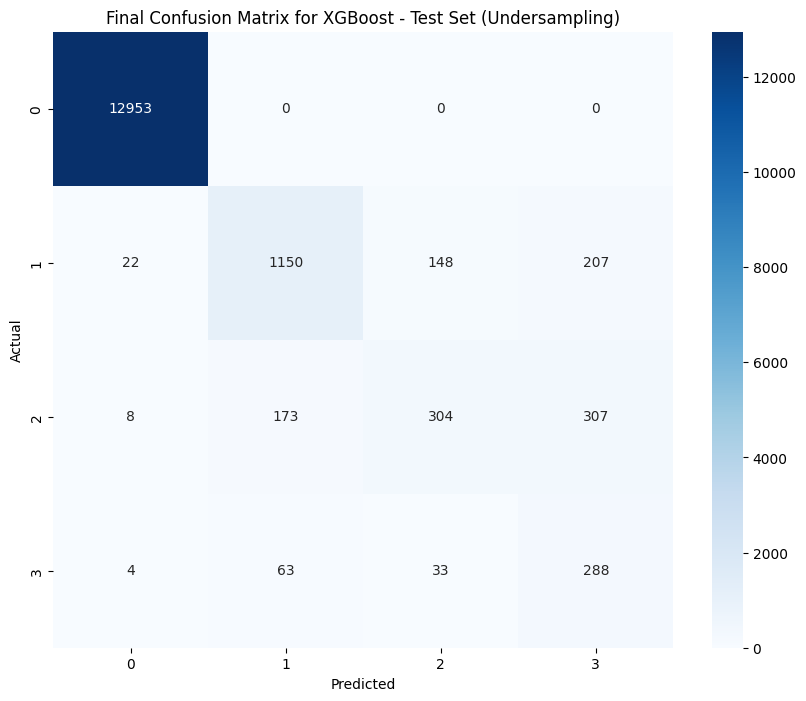

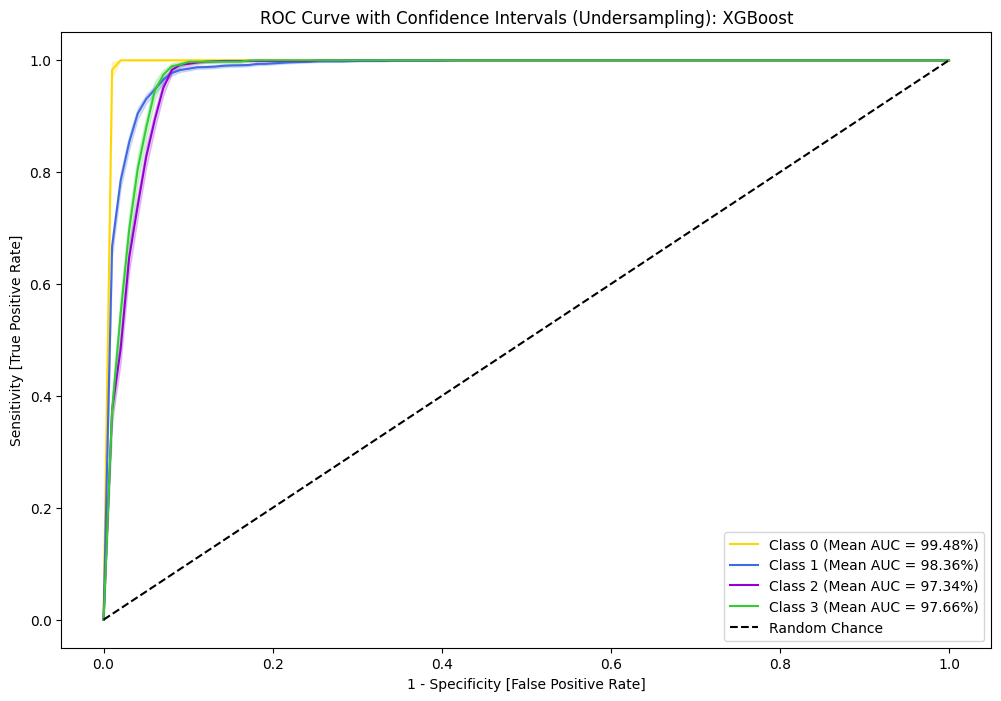


XGBoost train and test predictions have been saved separately.


In [1]:
import pandas as pd
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import auc, accuracy_score, f1_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from imblearn.pipeline import Pipeline  # Import the pipeline from imbalanced-learn
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import joblib
from imblearn.over_sampling import SMOTE  # Import SMOTE


# Load data
train_resampled_set = pd.read_csv('train_set.csv')
test_set = pd.read_csv('test_set.csv')

X_train = train_resampled_set.drop(columns=['N_claims_year', 'ID'])
y_train = train_resampled_set['N_claims_year']
X_test = test_set.drop(columns=['N_claims_year', 'ID'])
y_test = test_set['N_claims_year']

# Define parameter grids for each model
param_grid_xgb = {
    'model__n_estimators': [200],
    'model__learning_rate': [0.01],
    'model__max_depth': [7],
    'model__subsample': [0.7],
    'model__colsample_bytree': [0.7]
}
# {'model__subsample': 0.7, 'model__n_estimators': 200, 'model__max_depth': 7, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.7}

# Updated function with pipeline for undersampling
def nested_cv_model(model, param_grid, model_name, X_train, y_train, X_test, y_test):
    print(f"\nStarting Nested Cross-Validation for {model_name}...")

    # Define the pipeline with undersampling and the model
    pipeline = Pipeline([
        ('over', SMOTE(random_state=42)),  # Use SMOTE here
        ('model', model)
    ])

    # Inner cross-validation for hyperparameter tuning using the pipeline
    inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    search = RandomizedSearchCV(
        pipeline,
        param_distributions=param_grid,
        n_iter=10,
        scoring={'accuracy': 'accuracy', 'f1_weighted': 'f1_weighted'},
        refit='accuracy',
        cv=inner_cv,
        n_jobs=-1,
        random_state=42
    )

    # Outer cross-validation for model evaluation
    outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # Collect scores for each fold
    fold_results = []
    for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X_train, y_train), start=1):
        print(f"\nFold {fold}...")

        # Split data for this fold
        X_train_fold, X_test_fold = X_train.iloc[train_idx], X_train.iloc[test_idx]
        y_train_fold, y_test_fold = y_train.iloc[train_idx], y_train.iloc[test_idx]

        # Print class distribution in the original outer fold's training subset before resampling
        print("Original class distribution in training fold:", Counter(y_train_fold))

        # Inner cross-validation with hyperparameter tuning and resampling handled by the pipeline
        search.fit(X_train_fold, y_train_fold)

        # Evaluate on the outer test fold
        y_pred_fold = search.predict(X_test_fold)
        accuracy_fold = accuracy_score(y_test_fold, y_pred_fold)
        f1_fold = f1_score(y_test_fold, y_pred_fold, average='weighted')
        roc_auc_fold = roc_auc_score(pd.get_dummies(y_test_fold), pd.get_dummies(y_pred_fold), average='macro', multi_class='ovr')

        # Print fold results
        print(f"  Fold {fold} Accuracy: {accuracy_fold}")
        print(f"  Fold {fold} F1 Score: {f1_fold}")
        print(f"  Fold {fold} ROC AUC Score: {roc_auc_fold}")

        fold_results.append((fold, accuracy_fold, f1_fold, roc_auc_fold))

        # Plot confusion matrix for each fold
        conf_matrix = confusion_matrix(y_test_fold, y_pred_fold)
        plt.figure(figsize=(8, 6))
        sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
        plt.title(f"Confusion Matrix for {model_name} - Fold {fold}")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.savefig(f"{model_name}_conf_matrix_fold_{fold}.png")
        plt.close()

    # Train the best model on the entire training set
    search.fit(X_train, y_train)
    best_model = search.best_estimator_

    # Predictions on training and test sets
    y_pred_train = best_model.predict(X_train)
    y_pred_test = best_model.predict(X_test)
    y_pred_probabilities = best_model.predict_proba(X_test)

    # Evaluation metrics on test set
    accuracy = accuracy_score(y_test, y_pred_test)
    f1 = f1_score(y_test, y_pred_test, average='weighted')
    roc_auc = roc_auc_score(pd.get_dummies(y_test), y_pred_probabilities, average='macro', multi_class='ovr')

    class_report = classification_report(y_test, y_pred_test)
    conf_matrix = confusion_matrix(y_test, y_pred_test)

    # Display results
    print(f"\n{model_name} Best Parameters (pipeline with undersampling): {search.best_params_}")
    print(f"{model_name} Accuracy on Test Set: {accuracy}")
    print(f"{model_name} F1 Score on Test Set: {f1}")
    print(f"{model_name} ROC AUC Score on Test Set: {roc_auc}")
    print(f"{model_name} Classification Report:\n{class_report}")

    # Plot final confusion matrix for the test set
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
    plt.title(f"Final Confusion Matrix for {model_name} - Test Set (Undersampling)")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.savefig(f"{model_name}_final_conf_matrix.png")
    plt.show()

    # Updated ROC curve plotting with bootstrapped confidence intervals
    plt.figure(figsize=(12, 8))
    colors = ['gold', 'royalblue', 'darkviolet', 'limegreen']

    y_test_dummies = pd.get_dummies(y_test)
    bootstraps = 1000  # Number of bootstrap samples
    mean_fpr = np.linspace(0, 1, 100)

    for i, class_label in enumerate(np.unique(y_test)):
        tprs = []

        for _ in range(bootstraps):
            indices = np.random.randint(0, len(y_test), len(y_test))
            y_true_bootstrap = y_test_dummies.iloc[indices, i]
            y_pred_bootstrap = y_pred_probabilities[indices, i]
            fpr, tpr, _ = roc_curve(y_true_bootstrap, y_pred_bootstrap)
            tpr_interp = np.interp(mean_fpr, fpr, tpr)
            tpr_interp[0] = 0.0
            tprs.append(tpr_interp)

        mean_tpr = np.mean(tprs, axis=0)
        mean_tpr[-1] = 1.0
        mean_auc = auc(mean_fpr, mean_tpr)
        std_tpr = np.std(tprs, axis=0)

        plt.plot(mean_fpr, mean_tpr, color=colors[i % len(colors)], label=f'Class {class_label} (Mean AUC = {mean_auc:.2%})')
        plt.fill_between(mean_fpr, mean_tpr - std_tpr, mean_tpr + std_tpr, color=colors[i % len(colors)], alpha=0.2)

    plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
    plt.title(f"ROC Curve with Confidence Intervals (Undersampling): {model_name}")
    plt.xlabel("1 - Specificity [False Positive Rate]")
    plt.ylabel("Sensitivity [True Positive Rate]")
    plt.legend(loc='lower right')
    plt.savefig(f"{model_name}_roc_curve_with_ci_undersampling.png")
    plt.show()

    # Export separate CSVs for train and test set predictions
    train_df = X_train.copy()
    train_df['y_true_train'] = y_train
    train_df['y_pred_train'] = y_pred_train

    test_df = X_test.copy()
    test_df['y_true_test'] = y_test
    test_df['y_pred_test'] = y_pred_test

    train_df.to_csv(f"{model_name.lower().replace(' ', '_')}_train_undersampling_pipe.csv", index=False)
    test_df.to_csv(f"{model_name.lower().replace(' ', '_')}_test_undersampling_pipe.csv", index=False)
    print(f"\n{model_name} train and test predictions have been saved separately.")

    # Save the model
    joblib.dump(best_model, f"{model_name}_best_model.joblib")

    return fold_results, best_model

# 18 mins Run the nested CV with the XGBoost model as an example
fold_results_xgb, best_model_xgb = nested_cv_model(XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42), param_grid_xgb, 'XGBoost', X_train, y_train, X_test, y_test)


In [3]:
import pandas as pd 
xg = pd.read_csv("xgboost_test_undersampling_pipe.csv")
xg.describe()

,Distribution_channel,Seniority,Lapse,Payment,Premium,Cost_claims_year,N_claims_history,R_Claims_history,Type_risk,Area,...,Weight,Driving_experience_years,Age_Group_16-24,Age_Group_25-39,Age_Group_40-64,Age_Group_65+,Type_fuel_D,Type_fuel_P,y_true_test,y_pred_test
count,15660.000000,15660.000000,15660.000000,15660.000000,15660.000000,15660.000000,15660.000000,15660.000000,15660.0,15660.000000,...,15660.000000,15660.000000,15660.000000,15660.000000,15660.000000,15660.000000,15660.000000,15660.000000,15660.000000,15660.000000
mean,0.462388,6.544317,0.219923,0.347063,332.631309,123.300324,2.584100,0.404861,3.0,0.269604,...,1228.389080,23.960345,0.019285,0.316475,0.565453,0.098787,0.627969,0.372031,0.272989,0.304087
std,0.498599,6.235477,0.453227,0.476051,132.805860,723.176505,3.565757,0.670951,0.0,0.443768,...,224.777652,12.449241,0.137529,0.465115,0.495713,0.298385,0.483362,0.483362,0.669554,0.762152
min,0.000000,1.000000,0.000000,0.000000,41.100000,0.000000,0.000000,0.000000,3.0,0.000000,...,350.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,0.000000,0.000000,254.670000,0.000000,0.000000,0.000000,3.0,0.000000,...,1075.000000,14.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,4.000000,0.000000,0.000000,299.945000,0.000000,1.000000,0.110000,3.0,0.000000,...,1205.000000,23.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000
75%,1.000000,8.000000,0.000000,1.000000,370.937500,0.000000,4.000000,0.560000,3.0,1.000000,...,1357.000000,33.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000
max,1.000000,40.000000,5.000000,1.000000,1785.300000,25071.950000,49.000000,21.470000,3.0,1.000000,...,2643.000000,62.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000,3.000000



Starting Nested Cross-Validation for Logistic Regression...

Fold 1...
Original class distribution in training fold: Counter({0: 41448, 1: 4888, 2: 2534, 3: 1240})
  Fold 1 Accuracy: 0.915948275862069
  Fold 1 F1 Score: 0.9145599703647421
  Fold 1 ROC AUC Score: 0.791772745353342

Fold 2...
Original class distribution in training fold: Counter({0: 41448, 1: 4888, 2: 2533, 3: 1241})
  Fold 2 Accuracy: 0.9219348659003831
  Fold 2 F1 Score: 0.9226151782337118
  Fold 2 ROC AUC Score: 0.8069539649326477

Fold 3...
Original class distribution in training fold: Counter({0: 41448, 1: 4888, 2: 2533, 3: 1241})
  Fold 3 Accuracy: 0.9173052362707536
  Fold 3 F1 Score: 0.9183346112683838
  Fold 3 ROC AUC Score: 0.7930002747375797

Fold 4...
Original class distribution in training fold: Counter({0: 41448, 1: 4888, 2: 2534, 3: 1241})
  Fold 4 Accuracy: 0.9184162209627206
  Fold 4 F1 Score: 0.9194685725364591
  Fold 4 ROC AUC Score: 0.8018495095747575

Fold 5...
Original class distribution in trainin

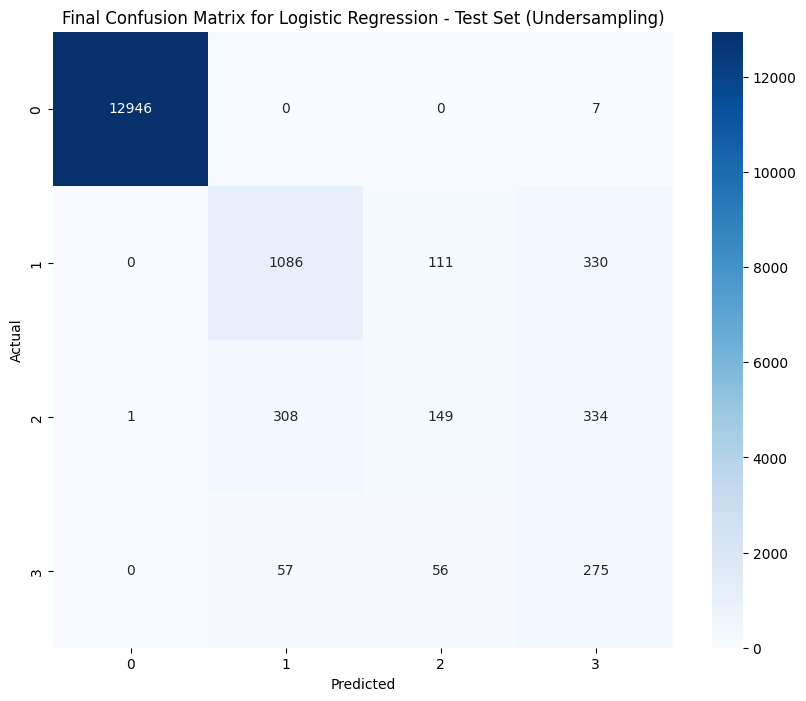

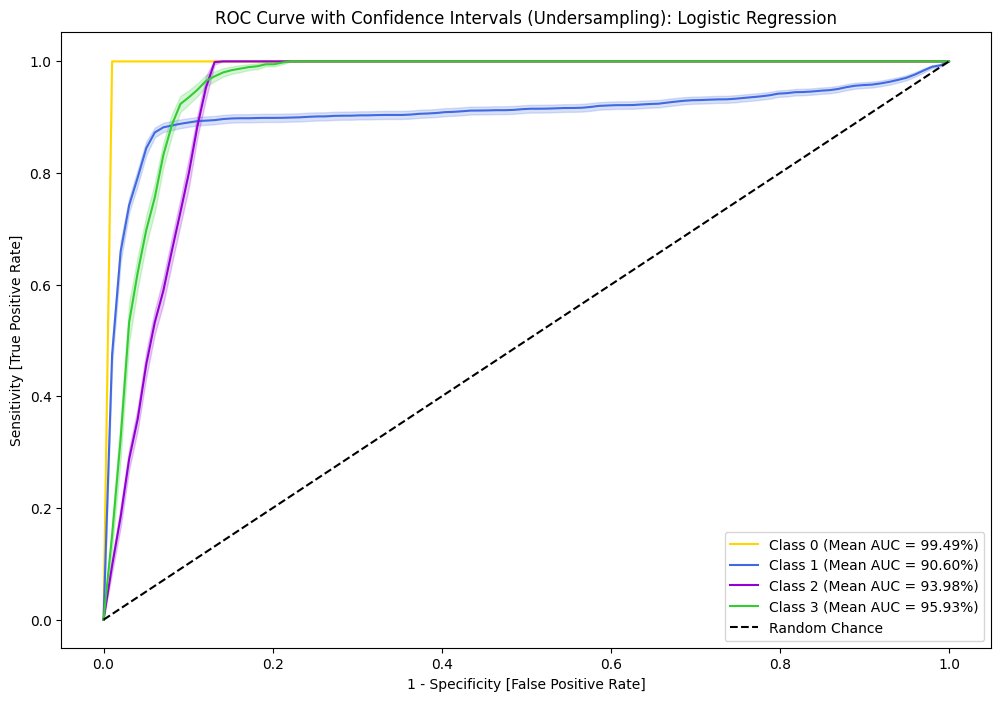


Logistic Regression train and test predictions have been saved separately.


In [ ]:
param_grid_lr = {
    'model__C': [0.01, 0.1, 1, 10],
    'model__solver': ['liblinear', 'lbfgs'],
    'model__max_iter': [100, 200, 500]
}


fold_results_lr, best_model_lr = nested_cv_model(
    LogisticRegression(random_state=42),           # Model for Logistic Regression
    param_grid_lr,                  # Parameter grid for Logistic Regression
    'Logistic Regression',          # Model name
    X_train,                        # Training features
    y_train,                        # Training labels
    X_test,                         # Test features
    y_test                          # Test labels
)

#14 mins


Starting Nested Cross-Validation for Random Forest...

Fold 1...
Original class distribution in training fold: Counter({0: 41448, 1: 4888, 2: 2534, 3: 1240})
  Fold 1 Accuracy: 0.9336685823754789
  Fold 1 F1 Score: 0.9358537498951714
  Fold 1 ROC AUC Score: 0.8415985897918069

Fold 2...
Original class distribution in training fold: Counter({0: 41448, 1: 4888, 2: 2533, 3: 1241})
  Fold 2 Accuracy: 0.9330300127713921
  Fold 2 F1 Score: 0.9334391049471574
  Fold 2 ROC AUC Score: 0.8166355092872217

Fold 3...
Original class distribution in training fold: Counter({0: 41448, 1: 4888, 2: 2533, 3: 1241})
  Fold 3 Accuracy: 0.9292784163473818
  Fold 3 F1 Score: 0.9290855178646243
  Fold 3 ROC AUC Score: 0.8056950461631012

Fold 4...
Original class distribution in training fold: Counter({0: 41448, 1: 4888, 2: 2534, 3: 1241})
  Fold 4 Accuracy: 0.9345413905963119
  Fold 4 F1 Score: 0.9337975673469366
  Fold 4 ROC AUC Score: 0.8175771513401833

Fold 5...
Original class distribution in training fo

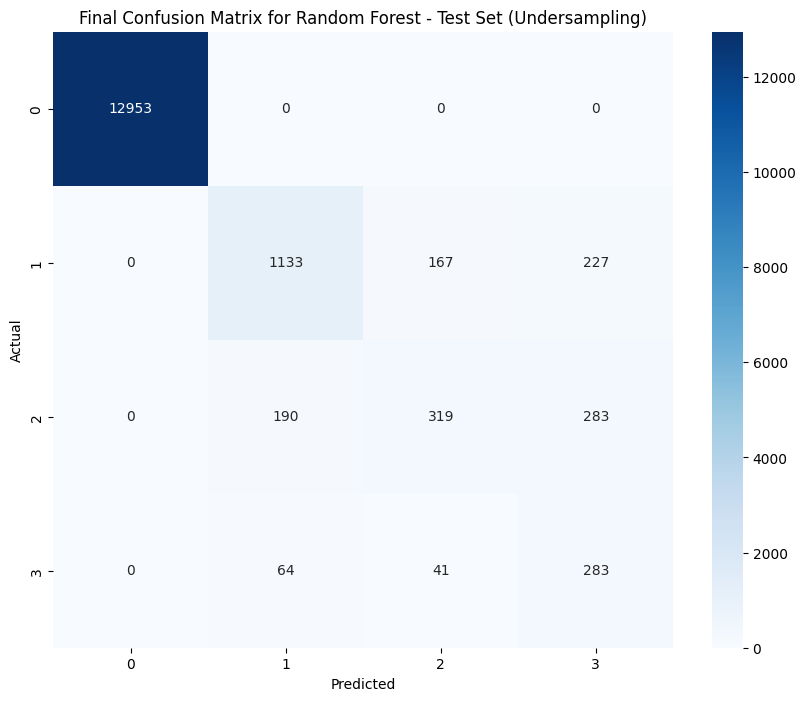

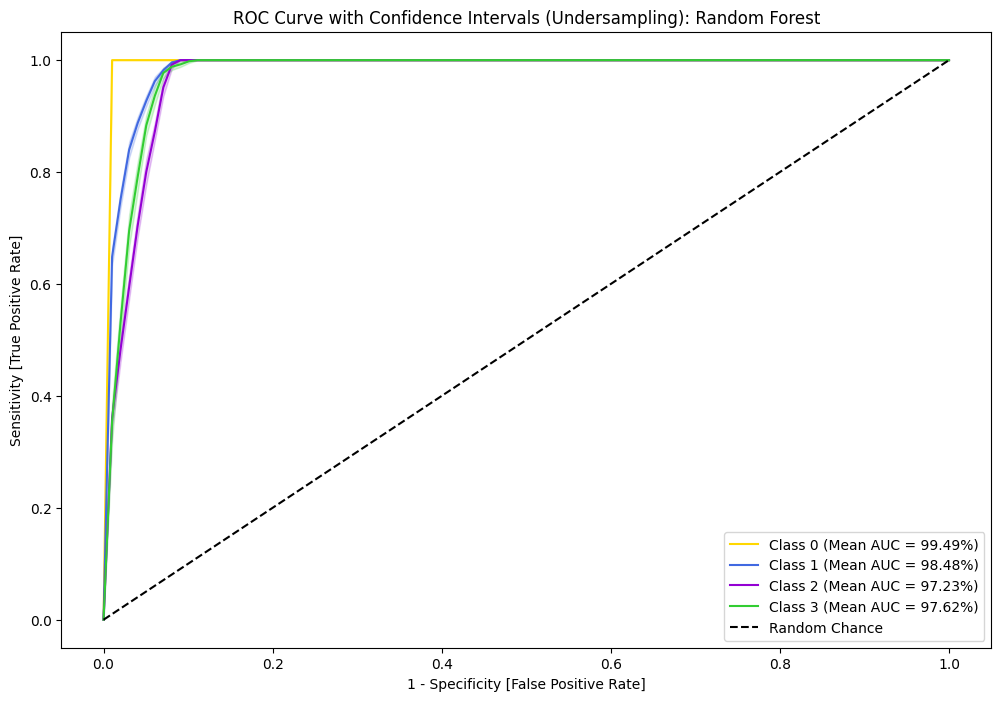


Random Forest train and test predictions have been saved separately.


In [ ]:
param_grid_rf = {
    'model__n_estimators': [50, 100, 200, 300],
    'model__max_depth': [None, 10, 20, 30],
    'model__min_samples_split': [2, 5, 10, 15],
    'model__min_samples_leaf': [1, 2, 4, 6]
}


fold_results_rf, best_model_rf = nested_cv_model(
    RandomForestClassifier(random_state=42),       # Model for Random Forest
    param_grid_rf,                  # Parameter grid for Random Forest
    'Random Forest',                # Model name
    X_train,                        # Training features
    y_train,                        # Training labels
    X_test,                         # Test features
    y_test                          # Test labels
) #63 mins


Starting Nested Cross-Validation for Gradient Boosting...

Fold 1...
Original class distribution in training fold: Counter({0: 41448, 1: 4888, 2: 2534, 3: 1240})
  Fold 1 Accuracy: 0.9390166028097062
  Fold 1 F1 Score: 0.9396060533417269
  Fold 1 ROC AUC Score: 0.8464109827405056

Fold 2...
Original class distribution in training fold: Counter({0: 41448, 1: 4888, 2: 2533, 3: 1241})
  Fold 2 Accuracy: 0.941411238825032
  Fold 2 F1 Score: 0.9420457761414627
  Fold 2 ROC AUC Score: 0.849820264691914

Fold 3...
Original class distribution in training fold: Counter({0: 41448, 1: 4888, 2: 2533, 3: 1241})
  Fold 3 Accuracy: 0.9366219667943806
  Fold 3 F1 Score: 0.9368700175114955
  Fold 3 ROC AUC Score: 0.8381227941183522

Fold 4...
Original class distribution in training fold: Counter({0: 41448, 1: 4888, 2: 2534, 3: 1241})
  Fold 4 Accuracy: 0.9386125967909316
  Fold 4 F1 Score: 0.9390053336767274
  Fold 4 ROC AUC Score: 0.8408219846272977

Fold 5...
Original class distribution in training 

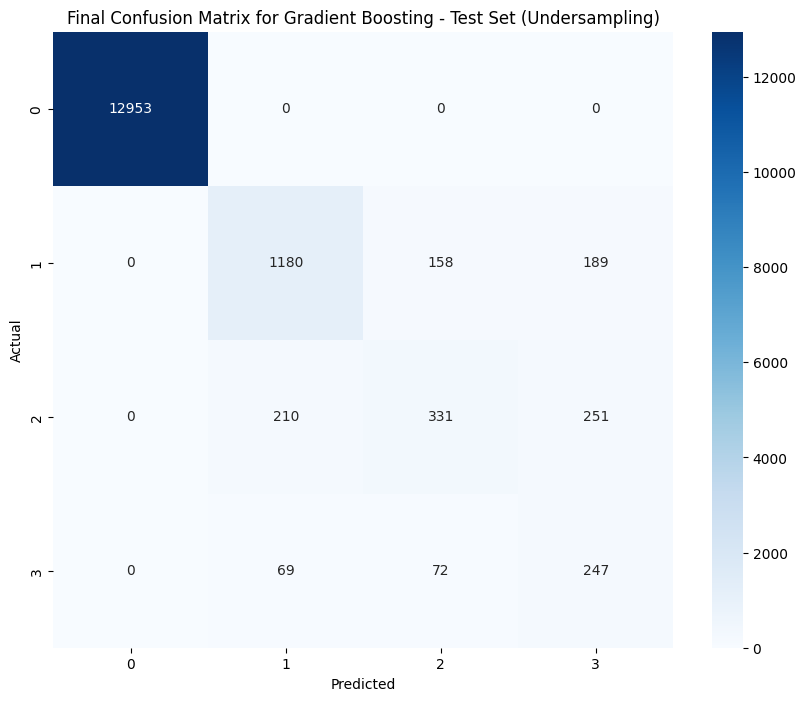

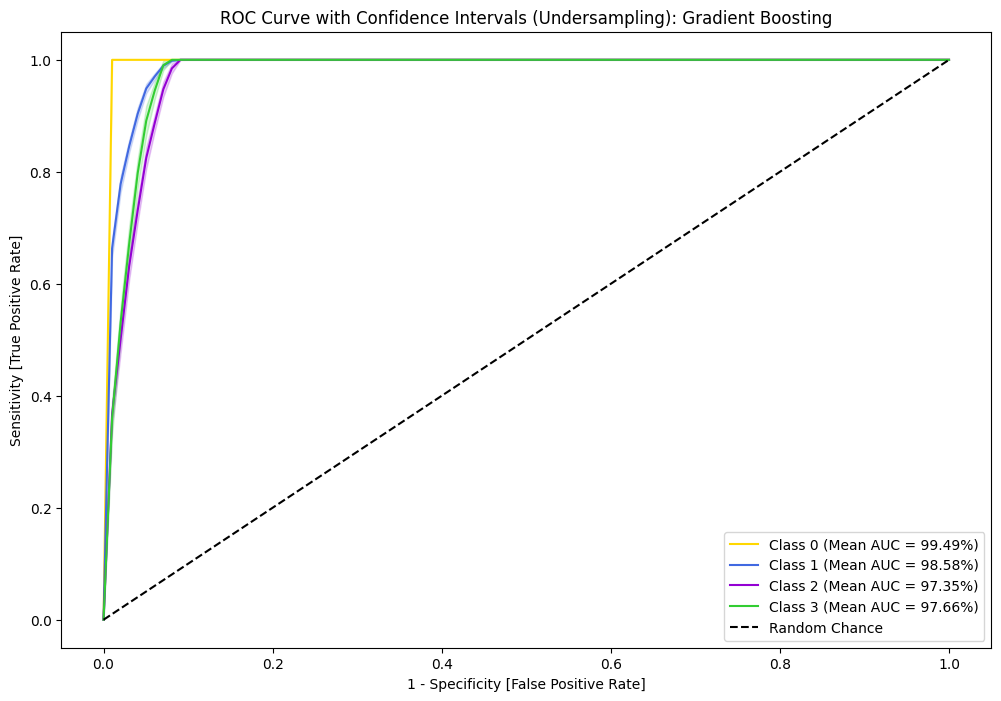


Gradient Boosting train and test predictions have been saved separately.


In [ ]:
param_grid_gb = {
    'model__n_estimators': [50, 100, 200, 300],
    'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'model__max_depth': [3, 5, 7, 9],
    'model__subsample': [0.6, 0.7, 0.8, 1.0]
}


fold_results_gb, best_model_gb = nested_cv_model(
    GradientBoostingClassifier(random_state=42),  # Model for Gradient Boosting
    param_grid_gb,                 # Parameter grid for Gradient Boosting
    'Gradient Boosting',            # Model name
    X_train,                        # Training features
    y_train,                        # Training labels
    X_test,                         # Test features
    y_test                          # Test labels
) #789 mins

In [10]:
import pandas as pd

# Assuming fold_results_xgb and fold_results_rf are lists of tuples like (fold, accuracy, f1, roc_auc)
# Example structure: [(1, 0.85, 0.82, 0.84), (2, 0.88, 0.83, 0.85), ...]

def export_fold_results_to_csv(fold_results, model_name):
    # Convert the fold results into a DataFrame
    fold_df = pd.DataFrame(fold_results, columns=['Fold', 'Accuracy', 'F1 Score', 'ROC AUC'])
    fold_df['Model'] = model_name  # Add a column for model name
    
    # Save DataFrame to CSV
    csv_filename = f"{model_name.lower().replace(' ', '_')}_fold_results.csv"
    fold_df.to_csv(csv_filename, index=False)
    print(f"Fold results for {model_name} have been saved to {csv_filename}")

# Export fold results for each model
export_fold_results_to_csv(fold_results_xgb, 'XGBoost')
export_fold_results_to_csv(fold_results_lr, "LogisticRegression")
export_fold_results_to_csv(fold_results_rf, 'Random Forest')
export_fold_results_to_csv(fold_results_gb, 'Gradient Boosting')

# For multiple models, concatenate results into a single table
# Example:
all_fold_results = pd.concat([
    pd.DataFrame(fold_results_xgb, columns=['Fold', 'Accuracy', 'F1 Score', 'ROC AUC']).assign(Model='XGBoost'),
    pd.DataFrame(fold_results_lr, columns=['Fold', 'Accuracy', 'F1 Score', 'ROC AUC']).assign(Model='Logistic Regression'),
    pd.DataFrame(fold_results_rf, columns=['Fold', 'Accuracy', 'F1 Score', 'ROC AUC']).assign(Model='Random Forest'),
    pd.DataFrame(fold_results_gb, columns=['Fold', 'Accuracy', 'F1 Score', 'ROC AUC']).assign(Model='Gradient Boosting')
])

# Export the combined results to a single CSV file
all_fold_results.to_csv("all_model_fold_results.csv", index=False)
print("All model fold results have been saved to all_model_fold_results.csv")


Fold results for XGBoost have been saved to xgboost_fold_results.csv
Fold results for LogisticRegression have been saved to logisticregression_fold_results.csv
Fold results for Random Forest have been saved to random_forest_fold_results.csv
Fold results for Gradient Boosting have been saved to gradient_boosting_fold_results.csv
All model fold results have been saved to all_model_fold_results.csv


In [11]:
import pandas as pd
from sklearn.metrics import classification_report
import joblib
from openpyxl import Workbook

def save_results_to_excel(model_name, classification_report, best_params):
    # Create a new Excel writer object
    excel_filename = f"{model_name.lower().replace(' ', '_')}_results.xlsx"
    with pd.ExcelWriter(excel_filename, engine='openpyxl') as writer:
        
        # Classification Report: Convert to DataFrame
        report_df = pd.DataFrame(classification_report).transpose()
        report_df.to_excel(writer, sheet_name="Classification Report")
        
        # Best Parameters: Convert to DataFrame
        best_params_df = pd.DataFrame([best_params]).transpose()
        best_params_df.columns = ['Best Value']  # Rename the column
        best_params_df.to_excel(writer, sheet_name="Best Parameters")
        
        print(f"Results for {model_name} have been saved to {excel_filename}")

# Example usage
# Replace these with actual values from your model runs
model_name_xgb = "XGBoost"
classification_report_xgb = classification_report(y_test, best_model_xgb.predict(X_test), output_dict=True)
best_params_xgb = best_model_xgb.get_params()  # Retrieve best parameters from the trained model
save_results_to_excel(model_name_xgb, classification_report_xgb, best_params_xgb)

# Repeat for other models if needed
model_name_rf = "Random Forest"
classification_report_rf = classification_report(y_test, best_model_rf.predict(X_test), output_dict=True)
best_params_rf = best_model_rf.get_params()
save_results_to_excel(model_name_rf, classification_report_rf, best_params_rf)

model_name_lr = "Logistic Regression"
classification_report_lr = classification_report(y_test, best_model_rf.predict(X_test), output_dict=True)
best_params_lr = best_model_lr.get_params()
save_results_to_excel(model_name_lr, classification_report_lr, best_params_lr)

model_name_gb = "Gredient Boosting"
classification_report_gb = classification_report(y_test, best_model_rf.predict(X_test), output_dict=True)
best_params_gb = best_model_gb.get_params()
save_results_to_excel(model_name_gb, classification_report_gb, best_params_gb)

ModuleNotFoundError: No module named 'openpyxl'

#### SHAP

c:\Users\Guest Hoefkestraat\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|===================| 62623/62640 [23:55<00:00]        

Generating SHAP plots for XGBoost - Class 0...
Generating SHAP plots for XGBoost - Class 1...
Generating SHAP plots for XGBoost - Class 2...
Generating SHAP plots for XGBoost - Class 3...
Generating manual SHAP summary plot for XGBoost - Class 0...
Generating manual SHAP summary plot for XGBoost - Class 1...
Generating manual SHAP summary plot for XGBoost - Class 2...
Generating manual SHAP summary plot for XGBoost - Class 3...


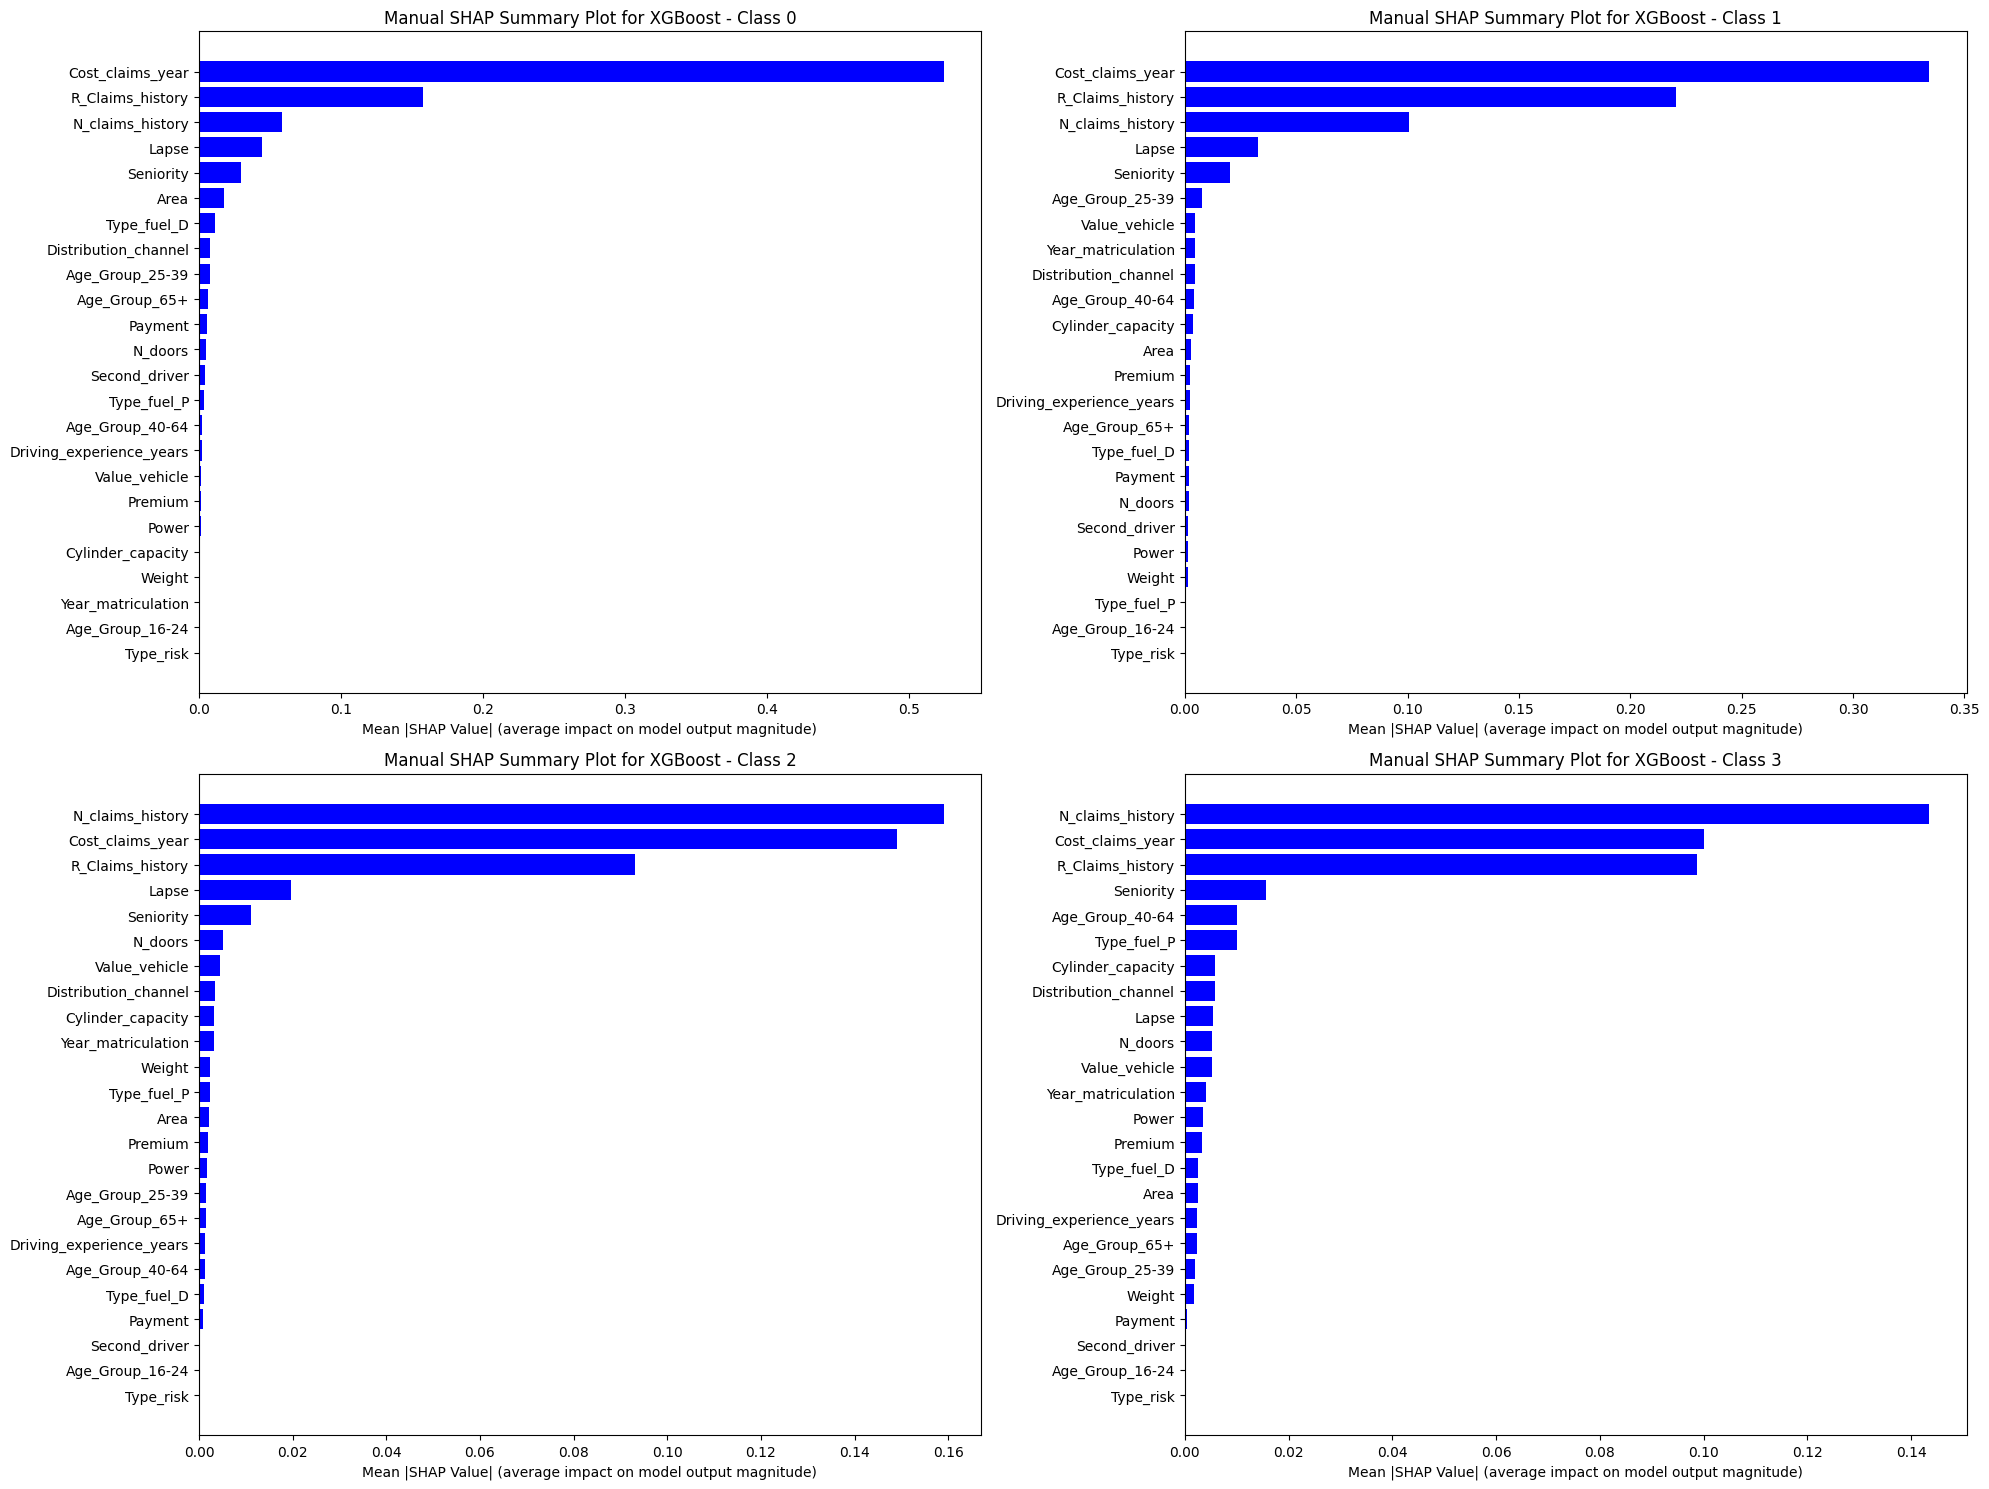

In [5]:
import shap # 13 mins 
import matplotlib.pyplot as plt
import numpy as np


def bee_plot(pipeline, model_name, X_train, X_test, num_classes=4, id_column='ID', random_state=42):
    # Drop the ID column if it exists
    if id_column in X_train.columns:
        X_train = X_train.drop(columns=[id_column])
    if id_column in X_test.columns:
        X_test = X_test.drop(columns=[id_column])
    
    # Extract the actual model from the pipeline
    model = pipeline.named_steps['model']
    
    # Initialize SHAP explainer and calculate SHAP values
    explainer = shap.Explainer(model, X_train)
    shap_values = explainer(X_test, check_additivity=False)
    
    # Plot SHAP values for each class
    for class_index in range(num_classes):
        print(f"Generating SHAP plots for {model_name} - Class {class_index}...")
        
        # SHAP values for the current class
        shap_values_class = shap_values[..., class_index]
        
        # Save SHAP summary plot
        shap.summary_plot(shap_values_class, X_test, show=False)
        plt.title(f'SHAP Summary Plot for {model_name} - Class {class_index} (undersampling)')
        plt.savefig(f"{model_name}_shap_summary_class_{class_index}_undersampling.png", bbox_inches='tight')
        plt.close()
    
    return shap_values
def summary_shap_plot(shap_values, X_test, model_name, num_classes=4, id_column='ID'):
    # Drop the ID column from the test set if it exists
    if id_column in X_test.columns:
        X_test = X_test.drop(columns=[id_column])
    
    # Create a single figure for all subplots
    fig, axes = plt.subplots(2, 2, figsize=(20, 15))
    axes = axes.flatten()

    # Generate manual SHAP summary plots for each class
    for class_index in range(num_classes):
        print(f"Generating manual SHAP summary plot for {model_name} - Class {class_index}...")

        # Extract SHAP values for the current class
        if num_classes > 1:
            shap_values_class = shap_values[..., class_index]
        else:
            shap_values_class = shap_values

        # Calculate mean absolute SHAP values for each feature and sort them
        mean_shap_values = np.abs(shap_values_class.values).mean(axis=0)
        sorted_indices = np.argsort(mean_shap_values)[::-1]  # Sort in descending order

        # Ensure the number of sorted indices does not exceed the number of columns in X_test
        num_features = min(len(sorted_indices), len(X_test.columns))

        # Plot on a specific subplot
        axes[class_index].barh(
            X_test.columns[sorted_indices][:num_features],
            mean_shap_values[sorted_indices][:num_features],
            color='blue'
        )
        axes[class_index].invert_yaxis()  # Invert y-axis to show the most important feature at the top
        axes[class_index].set_xlabel('Mean |SHAP Value| (average impact on model output magnitude)')
        axes[class_index].set_title(f'Manual SHAP Summary Plot for {model_name} - Class {class_index}')

    plt.tight_layout()
    plt.savefig(f"{model_name}_manual_shap_summary_all_classes_undersampling.png", bbox_inches='tight')
    plt.show()
        

# Example Usage
shap_values = bee_plot(best_model_xgb, 'XGBoost', X_train, X_test, random_state=42)
summary_shap_plot(shap_values, X_test, 'XGBoost')




In [6]:
import shap  # 3 mins
import matplotlib.pyplot as plt
import numpy as np

def bee_plot(pipeline, model_name, X_train, X_test, num_classes=4, id_column='ID', random_state=42):
    # Drop the ID column if it exists
    if id_column in X_train.columns:
        X_train = X_train.drop(columns=[id_column])
    if id_column in X_test.columns:
        X_test = X_test.drop(columns=[id_column])
    
    # Extract the actual model from the pipeline
    model = pipeline.named_steps['model']
    
    # Create SHAP explainer for the tree model (Random Forest)
    explainer = shap.TreeExplainer(model)
    shap_values = explainer(X_test, check_additivity=False)  # Disable additivity check if needed
    
    # Generate SHAP plots for each class and save them
    for class_index in range(num_classes):
        print(f"Generating SHAP plots for {model_name} - Class {class_index}...")
        
        # Extract SHAP values for the current class
        shap_values_class = shap_values[..., class_index] if num_classes > 1 else shap_values
        
        # Generate and save the SHAP summary plot
        shap.summary_plot(shap_values_class, X_test, show=False)
        plt.title(f'SHAP Summary Plot for {model_name} - Class {class_index} (undersampling)')
        plt.savefig(f"{model_name}_shap_summary_class_{class_index}_undersampling.png", bbox_inches='tight')
        plt.close()
    
    return shap_values  # Return SHAP values for further use

def summary_shap_plot(shap_values, X_test, model_name, num_classes=4, id_column='ID'):
    # Drop the ID column from the test set if it exists
    if id_column in X_test.columns:
        X_test = X_test.drop(columns=[id_column])
    
    # Generate manual SHAP summary plots for each class
    for class_index in range(num_classes):
        print(f"Generating manual SHAP summary plot for {model_name} - Class {class_index}...")

        # Extract SHAP values for the current class
        shap_values_class = shap_values[..., class_index] if num_classes > 1 else shap_values

        # Calculate mean absolute SHAP values for each feature and sort them
        mean_shap_values = np.abs(shap_values_class.values).mean(axis=0)
        sorted_indices = np.argsort(mean_shap_values)[::-1]  # Sort in descending order

        # Ensure the number of sorted indices does not exceed the number of columns in X_test
        num_features = min(len(sorted_indices), len(X_test.columns))

        plt.figure(figsize=(12, 8))
        plt.barh(
            X_test.columns[sorted_indices][:num_features],
            mean_shap_values[sorted_indices][:num_features],
            color='blue'
        )
        plt.xlabel('Mean |SHAP Value| (average impact on model output magnitude)')
        plt.title(f'Manual SHAP Summary Plot for {model_name} - Class {class_index} (undersampling)')
        plt.gca().invert_yaxis()  # Invert y-axis to show the most important feature at the top
        
        # Save the plot as a PNG file
        plt.savefig(f"{model_name}_manual_shap_summary_class_{class_index}_undersampling.png", bbox_inches='tight')
        plt.close()

# Run bee_plot to get SHAP values for the Random Forest model
shap_values_rf = bee_plot(best_model_rf, 'RandomForest', X_train, X_test, random_state=42)

# Use the SHAP values for the summary plots
summary_shap_plot(shap_values_rf, X_test, 'RandomForest')


Generating SHAP plots for RandomForest - Class 0...
Generating SHAP plots for RandomForest - Class 1...
Generating SHAP plots for RandomForest - Class 2...
Generating SHAP plots for RandomForest - Class 3...
Generating manual SHAP summary plot for RandomForest - Class 0...
Generating manual SHAP summary plot for RandomForest - Class 1...
Generating manual SHAP summary plot for RandomForest - Class 2...
Generating manual SHAP summary plot for RandomForest - Class 3...


                     Feature  Overall_Mean_Importance
5           Cost_claims_year                 0.223666
7           R_Claims_history                 0.065992
6           N_claims_history                 0.064587
2                      Lapse                 0.010929
20           Age_Group_40-64                 0.007273
0       Distribution_channel                 0.006828
19           Age_Group_25-39                 0.005405
1                  Seniority                 0.004092
22               Type_fuel_D                 0.003993
23               Type_fuel_P                 0.003386
21             Age_Group_65+                 0.003084
9                       Area                 0.003040
15                   N_doors                 0.002399
11        Year_matriculation                 0.001042
4                    Premium                 0.000907
10             Second_driver                 0.000859
14             Value_vehicle                 0.000734
17  Driving_experience_years

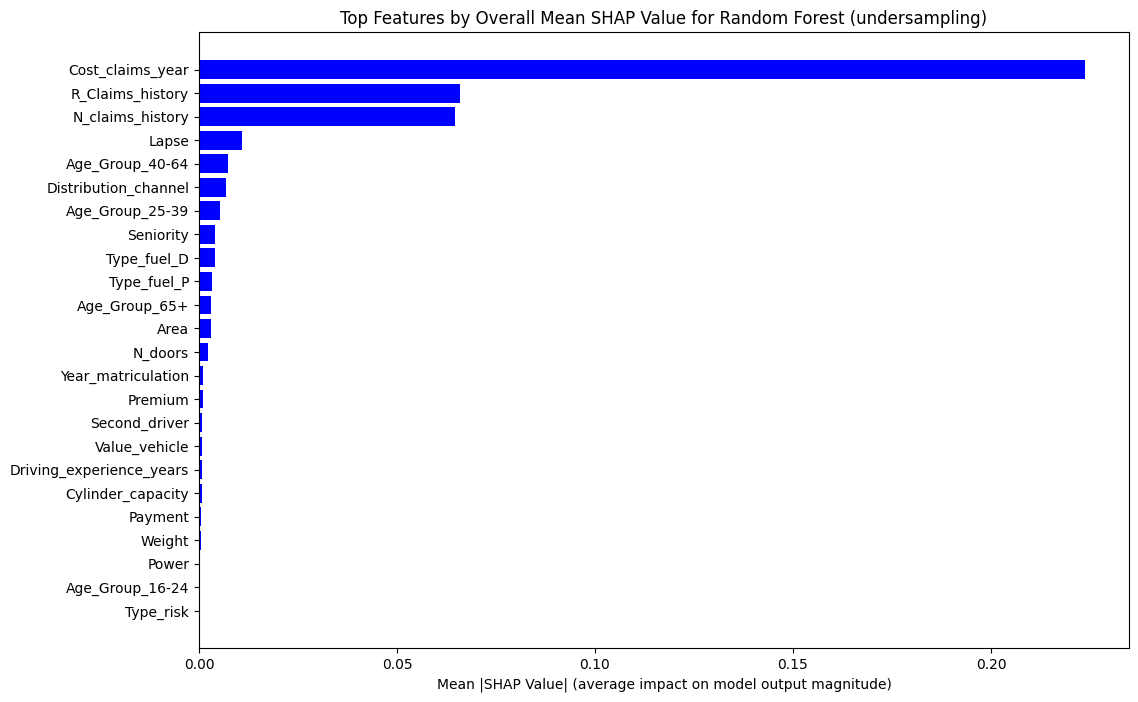

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def calculate_and_plot_overall_mean_shap_values(shap_values, X_test, model_name, num_classes=4, id_column='ID'):
    """
    Calculate mean SHAP values for each feature across all classes and plot the top features.
    
    Parameters:
    shap_values (shap._explanation.Explanation): SHAP values output from the explainer.
    X_test (pd.DataFrame): Test dataset to match feature names.
    model_name (str): Name of the model for plot labeling.
    num_classes (int): Number of classes in the multi-class classification.
    id_column (str): Column name to be dropped if present.
    
    Returns:
    pd.DataFrame: DataFrame of features sorted by overall mean SHAP importance.
    """
    # Drop the ID column from the test set if it exists
    if id_column in X_test.columns:
        X_test = X_test.drop(columns=[id_column])

    # Check if the number of features matches between shap_values and X_test
    num_features_shap = shap_values[..., 0].values.shape[1]  # Number of features in SHAP values
    num_features_test = X_test.shape[1]  # Number of features in X_test

    if num_features_shap != num_features_test:
        print(f"Warning: Number of features in SHAP values ({num_features_shap}) does not match number of features in X_test ({num_features_test}).")
        return None
    
    # Initialize a DataFrame to store mean absolute SHAP values for each feature and class
    feature_importance_df = pd.DataFrame()
    
    # Calculate mean absolute SHAP values for each class
    for class_index in range(num_classes):
        class_shap_values = shap_values[..., class_index].values  # Get SHAP values for the current class
        mean_abs_shap = np.abs(class_shap_values).mean(axis=0)  # Mean absolute SHAP value for each feature
        feature_importance_df[f'Class_{class_index}'] = mean_abs_shap
    
    # Add feature names from X_test
    feature_importance_df['Feature'] = X_test.columns[:num_features_shap]  # Match feature count

    # Calculate overall mean SHAP value across all classes for each feature
    feature_importance_df['Overall_Mean_Importance'] = feature_importance_df.iloc[:, :-1].mean(axis=1)
    
    # Sort features by overall mean importance
    feature_importance_df = feature_importance_df.sort_values(by='Overall_Mean_Importance', ascending=False)
    
    # Display the top features
    top_features = feature_importance_df[['Feature', 'Overall_Mean_Importance']]
    print(top_features)
    
    # Plot the top features
    plt.figure(figsize=(12, 8))
    plt.barh(top_features['Feature'], top_features['Overall_Mean_Importance'], color='blue')
    plt.xlabel('Mean |SHAP Value| (average impact on model output magnitude)')
    plt.title(f'Top Features by Overall Mean SHAP Value for {model_name} (undersampling)')
    plt.gca().invert_yaxis()  # Invert y-axis to show the most important feature at the top
    plt.show()
    
    return feature_importance_df

# Example usage to calculate overall mean SHAP values and plot the results
overall_feature_importance_df = calculate_and_plot_overall_mean_shap_values(shap_values_rf, X_test, "Random Forest", num_classes=4)


                     Feature  Overall_Mean_Importance
5           Cost_claims_year                 0.276858
7           R_Claims_history                 0.142559
6           N_claims_history                 0.115458
2                      Lapse                 0.025557
1                  Seniority                 0.019247
9                       Area                 0.006300
0       Distribution_channel                 0.005456
19           Age_Group_25-39                 0.004728
20           Age_Group_40-64                 0.004521
15                   N_doors                 0.004246
22               Type_fuel_D                 0.004180
23               Type_fuel_P                 0.004048
14             Value_vehicle                 0.003980
13         Cylinder_capacity                 0.003472
11        Year_matriculation                 0.003087
21             Age_Group_65+                 0.003076
4                    Premium                 0.002222
3                    Payment

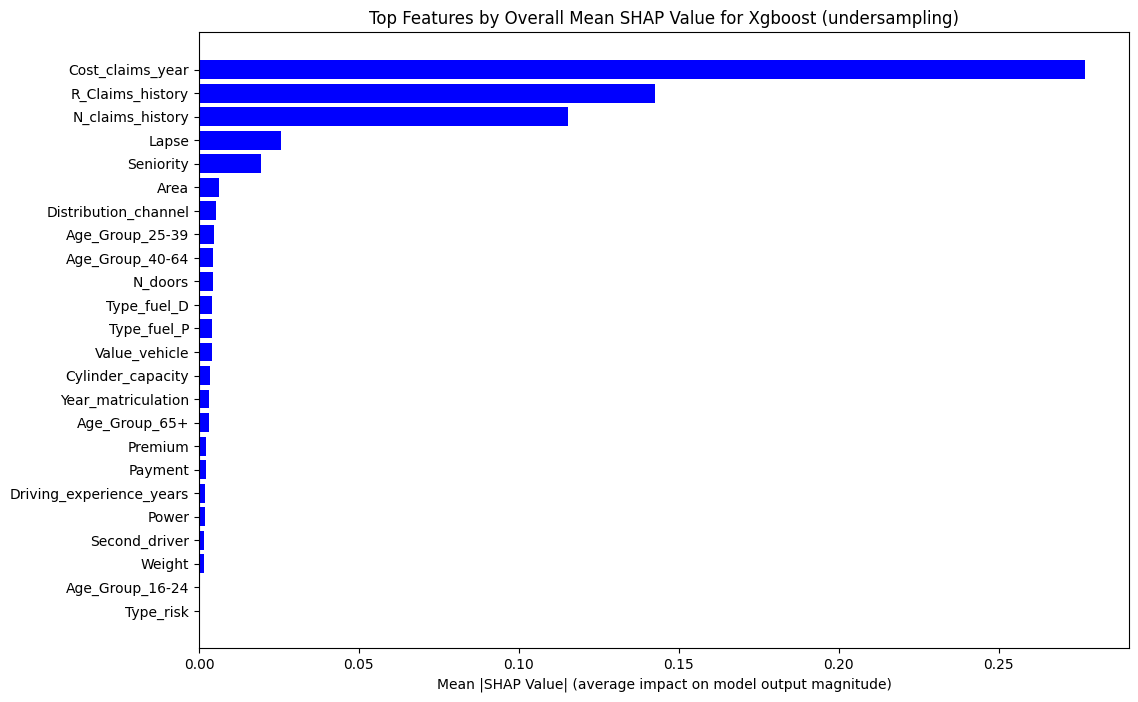

In [8]:
overall_feature_importance_df = calculate_and_plot_overall_mean_shap_values(shap_values, X_test, "Xgboost", num_classes=4)

                     Feature  Overall_Mean_Importance
5           Cost_claims_year                 0.250262
7           R_Claims_history                 0.104275
6           N_claims_history                 0.090022
2                      Lapse                 0.018243
1                  Seniority                 0.011670
0       Distribution_channel                 0.006142
20           Age_Group_40-64                 0.005897
19           Age_Group_25-39                 0.005066
9                       Area                 0.004670
22               Type_fuel_D                 0.004086
23               Type_fuel_P                 0.003717
15                   N_doors                 0.003323
21             Age_Group_65+                 0.003080
14             Value_vehicle                 0.002357
13         Cylinder_capacity                 0.002081
11        Year_matriculation                 0.002064
4                    Premium                 0.001564
17  Driving_experience_years

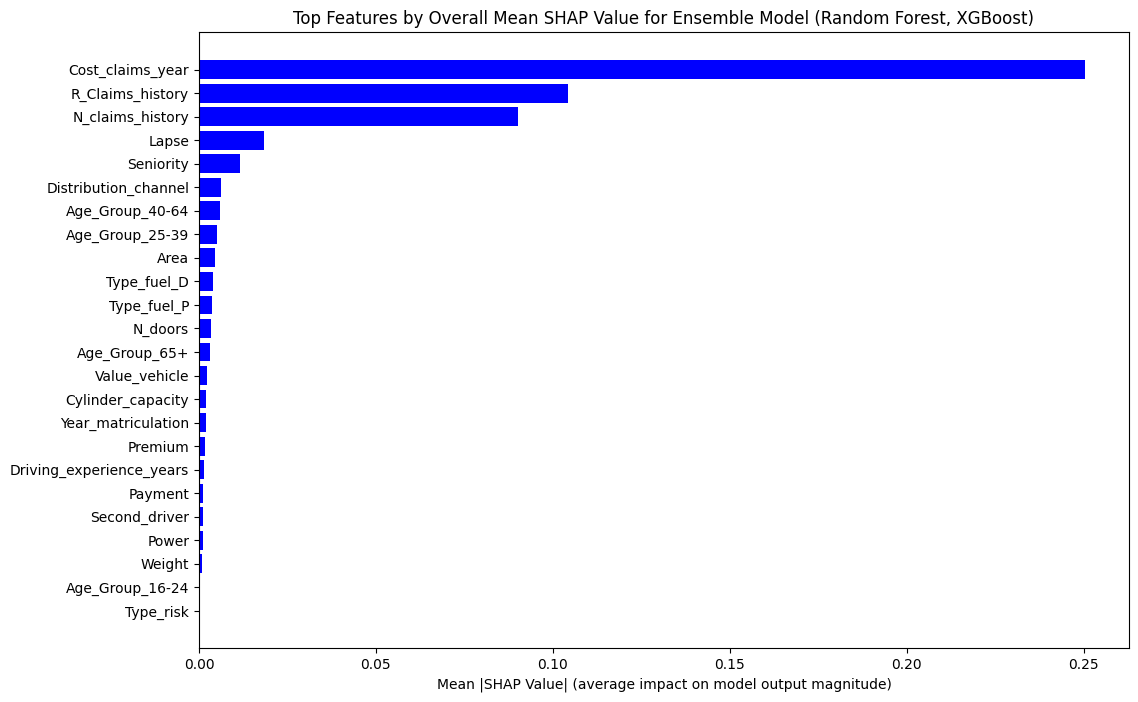

In [9]:
#mean of both rf and xg
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt

def calculate_and_plot_overall_mean_shap_values(shap_values_list, X_test, model_names, num_classes=4, id_column='ID'):
    """
    Calculate mean SHAP values for each feature across all classes and plot the top features.
    Allows for combining SHAP values from multiple models by averaging.

    Parameters:
    shap_values_list (list): List of SHAP values output from explainers for multiple models.
    X_test (pd.DataFrame): Test dataset to match feature names.
    model_names (list): List of model names for plot labeling.
    num_classes (int): Number of classes in the multi-class classification.
    id_column (str): Column name to be dropped if present.

    Returns:
    pd.DataFrame: DataFrame of features sorted by overall mean SHAP importance.
    """
    # Drop the ID column from the test set if it exists
    if id_column in X_test.columns:
        X_test = X_test.drop(columns=[id_column])

    # Initialize a DataFrame to store mean absolute SHAP values for each feature and class
    feature_importance_df = pd.DataFrame()

    # Calculate mean absolute SHAP values across models
    for class_index in range(num_classes):
        combined_shap_values = np.zeros(X_test.shape[1])

        # Iterate over each model's SHAP values
        for shap_values in shap_values_list:
            # Ensure shap_values has the correct number of features
            if shap_values[..., class_index].values.shape[1] != X_test.shape[1]:
                raise ValueError(f"Mismatch in features between SHAP values and X_test for class {class_index}.")

            # Accumulate SHAP values for each class
            combined_shap_values += np.abs(shap_values[..., class_index].values).mean(axis=0)

        # Average across all models
        mean_abs_shap = combined_shap_values / len(shap_values_list)
        feature_importance_df[f'Class_{class_index}'] = mean_abs_shap

    # Add feature names from X_test
    feature_importance_df['Feature'] = X_test.columns

    # Calculate overall mean SHAP value across all classes for each feature
    feature_importance_df['Overall_Mean_Importance'] = feature_importance_df.iloc[:, :-1].mean(axis=1)

    # Sort features by overall mean importance
    feature_importance_df = feature_importance_df.sort_values(by='Overall_Mean_Importance', ascending=False)

    # Display the top features
    top_features = feature_importance_df[['Feature', 'Overall_Mean_Importance']]
    print(top_features)

    # Plot the top features
    plt.figure(figsize=(12, 8))
    plt.barh(top_features['Feature'], top_features['Overall_Mean_Importance'], color='blue')
    plt.xlabel('Mean |SHAP Value| (average impact on model output magnitude)')
    plt.title(f'Top Features by Overall Mean SHAP Value for Ensemble Model ({", ".join(model_names)})')
    plt.gca().invert_yaxis()  # Invert y-axis to show the most important feature at the top
    plt.show()

    return feature_importance_df

# Example usage
# shap_values_rf = explainer_rf.shap_values(X_test)  # SHAP values for Random Forest
# shap_values_xg = explainer_xg.shap_values(X_test)  # SHAP values for XGBoost

# Assuming shap_values_rf and shap_values_xg are lists of SHAP values for each class
shap_values_list = [shap_values_rf, shap_values]
model_names = ["Random Forest", "XGBoost"]
overall_feature_importance_df = calculate_and_plot_overall_mean_shap_values(shap_values_list, X_test, model_names, num_classes=4)


#### SHAP_feature_Selection 

The next cell had already run with SMOTE for xgboost for more 10 mins, before I changed the saving name of files to smote. I decided to not rerun again, the name will include undersampling but It is smote.


Starting Nested Cross-Validation for XGBoost...

Fold 1...
Original class distribution in training fold_shap_undersampling: Counter({0: 41448, 1: 4888, 2: 2534, 3: 1240})


c:\Users\Guest Hoefkestraat\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\core.py:158: UserWarning: [06:11:57] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0ed59c031377d09b8-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


  Fold 1 Accuracy_shap_undersampling: 0.9379789272030651
  Fold 1 F1 Score_shap_undersampling: 0.9383482791727896
  Fold 1 ROC AUC Score_shap_undersampling: 0.8372902147806307

Fold 2...
Original class distribution in training fold_shap_undersampling: Counter({0: 41448, 1: 4888, 2: 2533, 3: 1241})


c:\Users\Guest Hoefkestraat\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\core.py:158: UserWarning: [06:14:13] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0ed59c031377d09b8-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


  Fold 2 Accuracy_shap_undersampling: 0.938617496807152
  Fold 2 F1 Score_shap_undersampling: 0.939144474483335
  Fold 2 ROC AUC Score_shap_undersampling: 0.8379210999108255

Fold 3...
Original class distribution in training fold_shap_undersampling: Counter({0: 41448, 1: 4888, 2: 2533, 3: 1241})


...

  Fold 4 Accuracy_shap_undersampling: 0.936377424762513
  Fold 4 F1 Score_shap_undersampling: 0.9370864468037836
  Fold 4 ROC AUC Score_shap_undersampling: 0.8300034307970922

Fold 5...
Original class distribution in training fold_shap_undersampling: Counter({0: 41448, 1: 4888, 2: 2534, 3: 1241})


c:\Users\Guest Hoefkestraat\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\core.py:158: UserWarning: [06:21:07] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0ed59c031377d09b8-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


  Fold 5 Accuracy_shap_undersampling: 0.9353396663207472
  Fold 5 F1 Score_shap_undersampling: 0.9367618050041839
  Fold 5 ROC AUC Score_shap_undersampling: 0.8346761182638228


c:\Users\Guest Hoefkestraat\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\core.py:158: UserWarning: [06:24:03] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0ed59c031377d09b8-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



XGBoost Best Parameters: {'model__subsample': 0.8, 'model__n_estimators': 100, 'model__max_depth': 7, 'model__learning_rate': 0.2, 'model__colsample_bytree': 1.0} (SHAP_undersampling)
XGBoost Accuracy on Test Set: 0.939272030651341 (SHAP_undersampling)
XGBoost F1 Score on Test Set: 0.9401552496488584 (SHAP_undersampling)
XGBoost ROC AUC Score on Test Set: 0.9840903146299609 (SHAP_undersampling)
XGBoost Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     12953
           1       0.80      0.76      0.78      1527
           2       0.56      0.49      0.52       792
           3       0.38      0.55      0.45       388

    accuracy                           0.94     15660
   macro avg       0.69      0.70      0.69     15660
weighted avg       0.94      0.94      0.94     15660
 (SHAP_undersampling)


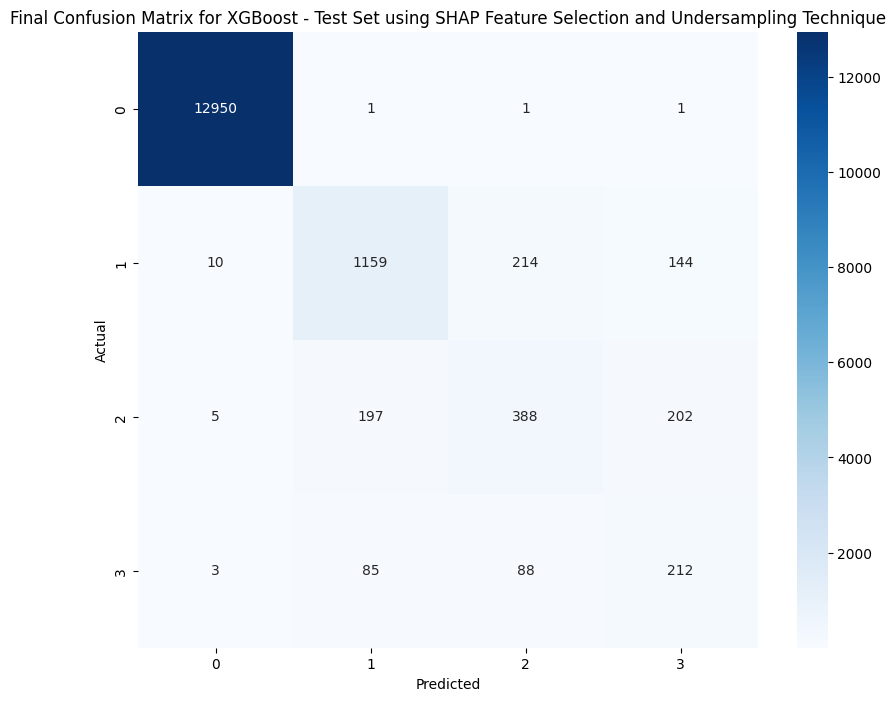

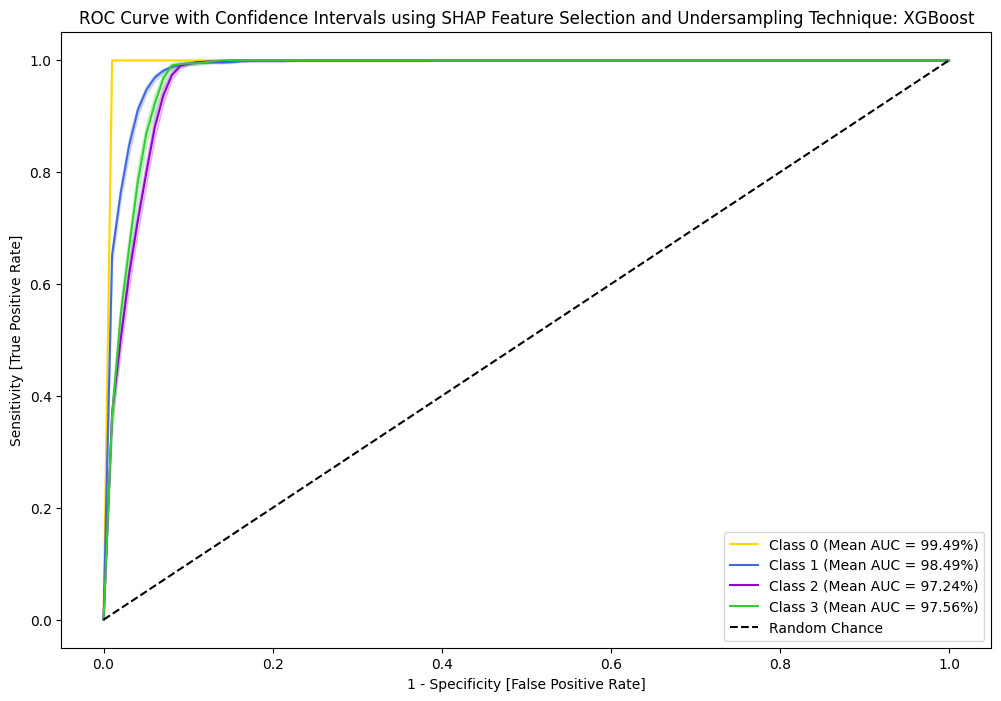


XGBoost train and test predictions have been saved separately.


In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, cross_val_score
import joblib
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

# Load data
train_resampled_set = pd.read_csv('train_set.csv')
test_set = pd.read_csv('test_set.csv')

# Define selected features for each model based on SHAP and SHAP analysis
selected_features_rf_SHAP = [
'Cost_claims_year',
'R_Claims_history',
'N_claims_history',
'Lapse',
'Age_Group_40-64',
'Distribution_channel',
'Age_Group_25-39',
'Seniority',
'Type_fuel_D',
'Type_fuel_P']

selected_features_xgb_SHAP = [
'Cost_claims_year',
'R_Claims_history',
'N_claims_history',
'Lapse',
'Seniority',
'Area',
'Distribution_channel',
'Age_Group_25-39',
'Age_Group_40-64',
'N_doors']

# Separate features and target for training and test sets
X_train_rf = train_resampled_set[selected_features_rf_SHAP]
X_train_xgb = train_resampled_set[selected_features_xgb_SHAP]

y_train_resampled = train_resampled_set['N_claims_year']

X_test_rf = test_set[selected_features_rf_SHAP]
X_test_xgb = test_set[selected_features_xgb_SHAP]

y_test = test_set['N_claims_year']

# Define parameter grids for each model

param_grid_xgb = {
    'model__n_estimators': [50, 100, 200],
    'model__learning_rate': [0.01, 0.1, 0.2],
    'model__max_depth': [3, 5, 7],
    'model__subsample': [0.7, 0.8, 1.0],
    'model__colsample_bytree': [0.7, 0.8, 1.0]
}
# Updated function with pipeline for smote
def nested_cv_model(model, param_grid, model_name, X_train, y_train, X_test, y_test):
    print(f"\nStarting Nested Cross-Validation for {model_name}...")

    # Define the pipeline with smote and the model
    pipeline = Pipeline([
        ('under', SMOTE(random_state=42)),
        ('model', model)
    ])

    # Inner cross-validation for hyperparameter tuning using the pipeline
    inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    search = RandomizedSearchCV(
        pipeline,
        param_distributions=param_grid,
        n_iter=10,
        scoring={'accuracy': 'accuracy', 'f1_weighted': 'f1_weighted'},
        refit='accuracy',
        cv=inner_cv,
        n_jobs=-1,
        random_state=42
    )

    # Outer cross-validation for model evaluation
    outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # Collect scores for each fold
    fold_results = []
    for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X_train, y_train), start=1):
        print(f"\nFold {fold}...")

        # Split data for this fold
        X_train_fold, X_test_fold = X_train.iloc[train_idx], X_train.iloc[test_idx]
        y_train_fold, y_test_fold = y_train.iloc[train_idx], y_train.iloc[test_idx]

        # Print class distribution in the original outer fold's training subset before resampling
        print("Original class distribution in training fold_shap_smote:", Counter(y_train_fold))

        # Inner cross-validation with hyperparameter tuning and resampling handled by the pipeline
        search.fit(X_train_fold, y_train_fold)

        # Evaluate on the outer test fold
        y_pred_fold = search.predict(X_test_fold)
        accuracy_fold = accuracy_score(y_test_fold, y_pred_fold)
        f1_fold = f1_score(y_test_fold, y_pred_fold, average='weighted')
        roc_auc_fold = roc_auc_score(pd.get_dummies(y_test_fold), pd.get_dummies(y_pred_fold), average='macro', multi_class='ovr')

        # Print fold results
        print(f"  Fold {fold} Accuracy_shap_smote: {accuracy_fold}")
        print(f"  Fold {fold} F1 Score_shap_smote: {f1_fold}")
        print(f"  Fold {fold} ROC AUC Score_shap_smote: {roc_auc_fold}")

        fold_results.append((fold, accuracy_fold, f1_fold, roc_auc_fold))


        # Plot confusion matrix for each fold
        conf_matrix = confusion_matrix(y_test_fold, y_pred_fold)
        plt.figure(figsize=(8, 6))
        sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
        plt.title(f"Confusion Matrix for {model_name} - Fold {fold} using SHAP Feature Selection and smote Technique")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.savefig(f"{model_name}_conf_matrix_fold_{fold}_SHAP_smote.png")
        plt.close()

    # Train the best model on the entire training set
    search.fit(X_train, y_train)
    best_model = search.best_estimator_

    # Predictions on training and test sets
    y_pred_train = best_model.predict(X_train)
    y_pred_test = best_model.predict(X_test)
    y_pred_probabilities = best_model.predict_proba(X_test)

    # Evaluation metrics on test set
    accuracy = accuracy_score(y_test, y_pred_test)
    f1 = f1_score(y_test, y_pred_test, average='weighted')
    roc_auc = roc_auc_score(pd.get_dummies(y_test), y_pred_probabilities, average='macro', multi_class='ovr')

    class_report = classification_report(y_test, y_pred_test)
    conf_matrix = confusion_matrix(y_test, y_pred_test)

    # Display results
    print(f"\n{model_name} Best Parameters: {search.best_params_} (SHAP_smote)")
    print(f"{model_name} Accuracy on Test Set: {accuracy} (SHAP_smote)")
    print(f"{model_name} F1 Score on Test Set: {f1} (SHAP_smote)")
    print(f"{model_name} ROC AUC Score on Test Set: {roc_auc} (SHAP_smote)")
    print(f"{model_name} Classification Report:\n{class_report} (SHAP_smote)")

    # Plot final confusion matrix for the test set
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
    plt.title(f"Final Confusion Matrix for {model_name} - Test Set using SHAP Feature Selection and smote Technique")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.savefig(f"{model_name}_final_conf_matrix_boru_smote.png")
    plt.show()

    # Updated ROC curve plotting with bootstrapped confidence intervals
    plt.figure(figsize=(12, 8))
    colors = ['gold', 'royalblue', 'darkviolet', 'limegreen']

    y_test_dummies = pd.get_dummies(y_test)
    bootstraps = 1000  # Number of bootstrap samples
    mean_fpr = np.linspace(0, 1, 100)

    for i, class_label in enumerate(np.unique(y_test)):
        tprs = []

        for _ in range(bootstraps):
            indices = np.random.randint(0, len(y_test), len(y_test))
            y_true_bootstrap = y_test_dummies.iloc[indices, i]
            y_pred_bootstrap = y_pred_probabilities[indices, i]
            fpr, tpr, _ = roc_curve(y_true_bootstrap, y_pred_bootstrap)
            tpr_interp = np.interp(mean_fpr, fpr, tpr)
            tpr_interp[0] = 0.0
            tprs.append(tpr_interp)

        mean_tpr = np.mean(tprs, axis=0)
        mean_tpr[-1] = 1.0
        mean_auc = auc(mean_fpr, mean_tpr)
        std_tpr = np.std(tprs, axis=0)

        plt.plot(mean_fpr, mean_tpr, color=colors[i % len(colors)], label=f'Class {class_label} (Mean AUC = {mean_auc:.2%})')
        plt.fill_between(mean_fpr, mean_tpr - std_tpr, mean_tpr + std_tpr, color=colors[i % len(colors)], alpha=0.2)

    plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
    plt.title(f"ROC Curve with Confidence Intervals using SHAP Feature Selection and smote Technique: {model_name}")
    plt.xlabel("1 - Specificity [False Positive Rate]")
    plt.ylabel("Sensitivity [True Positive Rate]")
    plt.legend(loc='lower right')
    plt.savefig(f"{model_name}_roc_curve_with_ci_(SHAP_smote).png")
    plt.show()

    # Export separate CSVs for train and test set predictions
    train_df = X_train.copy()
    train_df['y_true_train'] = y_train
    train_df['y_pred_train'] = y_pred_train

    test_df = X_test.copy()
    test_df['y_true_test'] = y_test
    test_df['y_pred_test'] = y_pred_test

    train_df.to_csv(f"{model_name.lower().replace(' ', '_')}_train_(SHAP_smote).csv", index=False)
    test_df.to_csv(f"{model_name.lower().replace(' ', '_')}_test_(SHAP_smote).csv", index=False)
    print(f"\n{model_name} train and test predictions have been saved separately.")

    # Save the model
    joblib.dump(best_model, f"{model_name}_best_model_(SHAP_smote).joblib")

    return fold_results, best_model

param_grid_xgb_SHAP = {
    'model__n_estimators': [50, 100, 200],
    'model__learning_rate': [0.01, 0.1, 0.2],
    'model__max_depth': [3, 5, 7],
    'model__subsample': [0.7, 0.8, 1.0],
    'model__colsample_bytree': [0.7, 0.8, 1.0]
}

# Example call for each model
fold_results_xgb_shap, best_model_xgb_shap = nested_cv_model(
    XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42),
    param_grid_xgb_SHAP,
    'XGBoost',
    X_train_xgb,
    y_train_resampled,
    X_test_xgb,
    y_test
)
#14 mins

In [2]:
import pandas as pd 
xg = pd.read_csv("XGBoost_test_(SHAP_smote).csv")

FileNotFoundError: [Errno 2] No such file or directory: 'XGBoost_test_(SHAP_smote).csv'


Starting Nested Cross-Validation for Random Forest...

Fold 1...
Original class distribution in training fold_shap_undersampling: Counter({0: 41448, 1: 4888, 2: 2534, 3: 1240})
  Fold 1 Accuracy_shap_undersampling: 0.9345466155810983
  Fold 1 F1 Score_shap_undersampling: 0.9357512053855345
  Fold 1 ROC AUC Score_shap_undersampling: 0.8326157232140632

Fold 2...
Original class distribution in training fold_shap_undersampling: Counter({0: 41448, 1: 4888, 2: 2533, 3: 1241})
  Fold 2 Accuracy_shap_undersampling: 0.9379789272030651
  Fold 2 F1 Score_shap_undersampling: 0.9385666803879683
  Fold 2 ROC AUC Score_shap_undersampling: 0.8364916370427247

Fold 3...
Original class distribution in training fold_shap_undersampling: Counter({0: 41448, 1: 4888, 2: 2533, 3: 1241})
  Fold 3 Accuracy_shap_undersampling: 0.933588761174968
  Fold 3 F1 Score_shap_undersampling: 0.9338101203421343
  Fold 3 ROC AUC Score_shap_undersampling: 0.8210834024275071

Fold 4...
Original class distribution in trainin

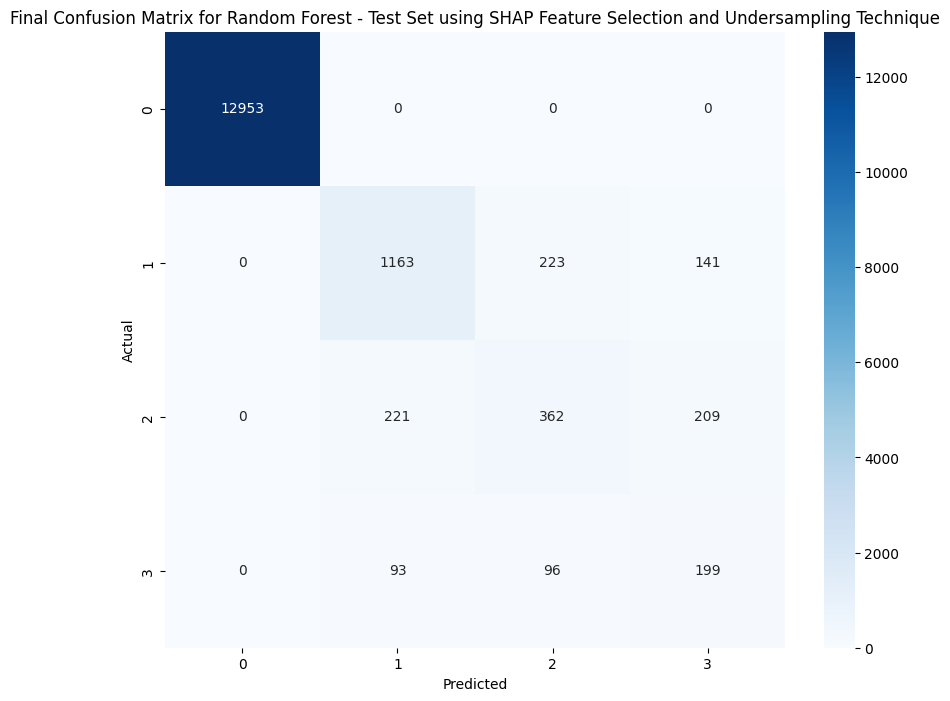

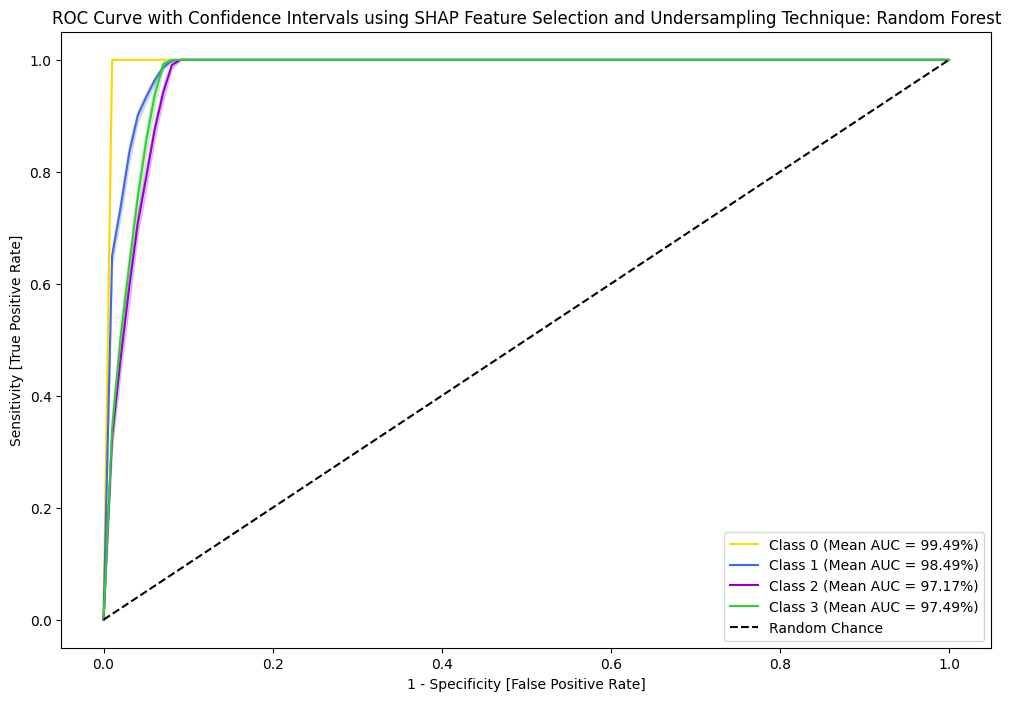


Random Forest train and test predictions have been saved separately.


In [13]:
param_grid_rf_shap = {
    'model__n_estimators': [50, 100, 200, 300],
    'model__max_depth': [None, 10, 20, 30],
    'model__min_samples_split': [2, 5, 10, 15],
    'model__min_samples_leaf': [1, 2, 4, 6]
}


fold_results_rf_shap, best_model_rf_shap = nested_cv_model(
    RandomForestClassifier(random_state=42),       # Model for Random Forest
    param_grid_rf_shap,                  # Parameter grid for Random Forest
    'Random Forest',                # Model name
    X_train_rf,                        # Training features
    y_train,                        # Training labels
    X_test_rf,                         # Test features
    y_test                          # Test labels
) #63 mins

# Logistic and GB _shap


Starting Nested Cross-Validation for Logistic Regression...

Fold 1...
Original class distribution in training fold_shap_smote: Counter({0: 41448, 1: 4888, 2: 2534, 3: 1240})


c:\Users\Guest Hoefkestraat\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


  Fold 1 Accuracy_shap_smote: 0.9198595146871009
  Fold 1 F1 Score_shap_smote: 0.9229348436209006
  Fold 1 ROC AUC Score_shap_smote: 0.8008663039718633

Fold 2...
Original class distribution in training fold_shap_smote: Counter({0: 41448, 1: 4888, 2: 2533, 3: 1241})


c:\Users\Guest Hoefkestraat\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


  Fold 2 Accuracy_shap_smote: 0.9202586206896551
  Fold 2 F1 Score_shap_smote: 0.9186716611219243
  Fold 2 ROC AUC Score_shap_smote: 0.8037938854571443

Fold 3...
Original class distribution in training fold_shap_smote: Counter({0: 41448, 1: 4888, 2: 2533, 3: 1241})


...

  Fold 4 Accuracy_shap_smote: 0.9213698411431308
  Fold 4 F1 Score_shap_smote: 0.9206068755493363
  Fold 4 ROC AUC Score_shap_smote: 0.8018195898499444

Fold 5...
Original class distribution in training fold_shap_smote: Counter({0: 41448, 1: 4888, 2: 2534, 3: 1241})


c:\Users\Guest Hoefkestraat\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


  Fold 5 Accuracy_shap_smote: 0.9188153588249381
  Fold 5 F1 Score_shap_smote: 0.9177166710625849
  Fold 5 ROC AUC Score_shap_smote: 0.8012042629647167


c:\Users\Guest Hoefkestraat\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\Guest Hoefkestraat\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    h


Logistic Regression Best Parameters: {'model__solver': 'lbfgs', 'model__max_iter': 200, 'model__C': 10} (SHAP_smote)
Logistic Regression Accuracy on Test Set: 0.925095785440613 (SHAP_smote)
Logistic Regression F1 Score on Test Set: 0.9239308633941642 (SHAP_smote)
Logistic Regression ROC AUC Score on Test Set: 0.9729046308497002 (SHAP_smote)
Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     12953
           1       0.72      0.73      0.73      1527
           2       0.43      0.25      0.32       792
           3       0.31      0.56      0.40       388

    accuracy                           0.93     15660
   macro avg       0.62      0.64      0.61     15660
weighted avg       0.93      0.93      0.92     15660
 (SHAP_smote)


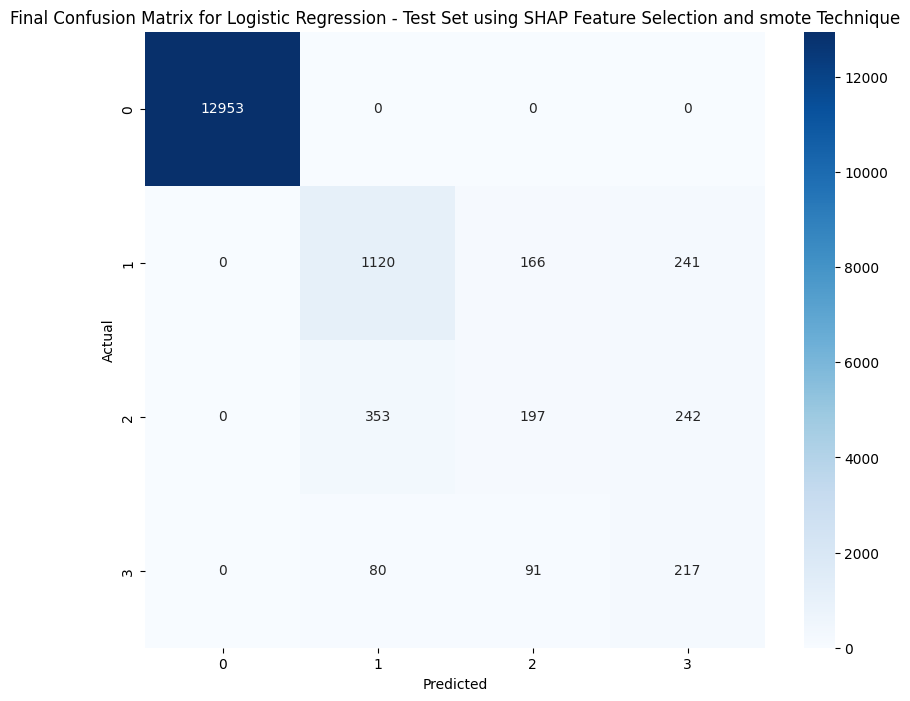

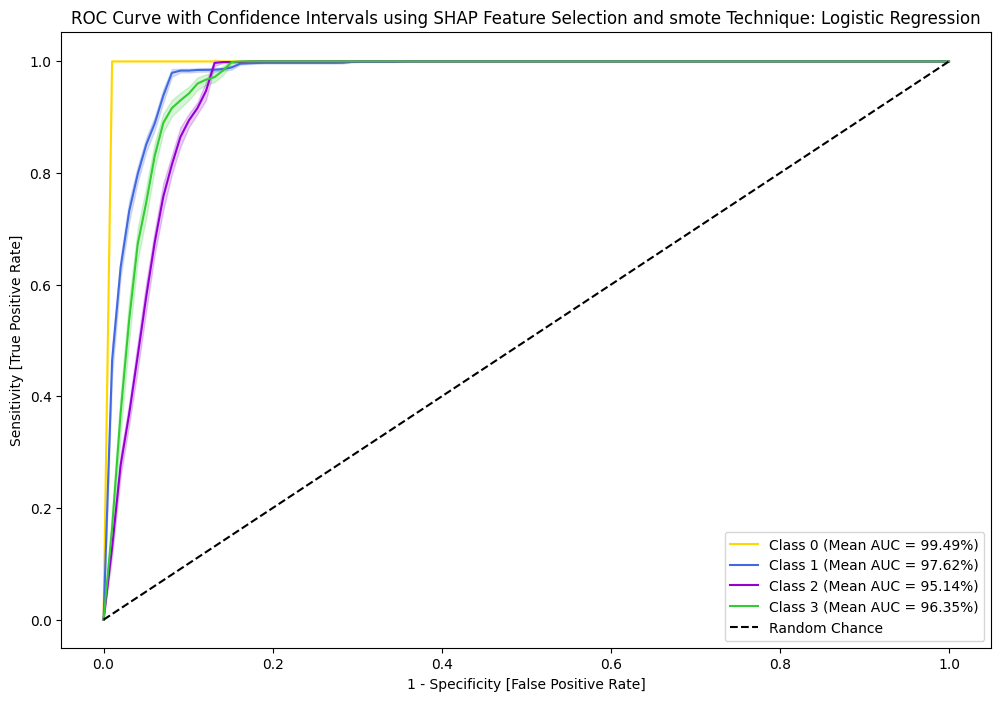


Logistic Regression train and test predictions have been saved separately.


In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, cross_val_score
import joblib
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

# Load data 14 mins
train_resampled_set = pd.read_csv('train_set.csv')
test_set = pd.read_csv('test_set.csv')

# Define selected features for each model based on SHAP and SHAP analysis
selected_features_SHAP = [
'Cost_claims_year',
'R_Claims_history',
'N_claims_history',
'Lapse',
'Seniority',
'Distribution_channel',
'Age_Group_40-64',
'Age_Group_25-39',
'Area',
'Type_fuel_D']

# Separate features and target for training and test sets
X_train_lr = train_resampled_set[selected_features_SHAP]
X_train_gb = train_resampled_set[selected_features_SHAP]
y_train_resampled = train_resampled_set['N_claims_year']

X_test_lr = test_set[selected_features_SHAP]
X_test_gb = test_set[selected_features_SHAP]
y_test = test_set['N_claims_year']

# Updated function with reduced parallelism and folds
def nested_cv_model(model, param_grid, model_name, X_train, y_train, X_test, y_test):
    print(f"\nStarting Nested Cross-Validation for {model_name}...")

    # Define the pipeline with smote and the model
    pipeline = Pipeline([
        ('under', SMOTE(random_state=42)),
        ('model', model)
    ])

    # Inner cross-validation with reduced parallel jobs and folds
    inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    search = RandomizedSearchCV(
        pipeline,
        param_distributions=param_grid,
        n_iter=10,
        scoring={'accuracy': 'accuracy', 'f1_weighted': 'f1_weighted'},
        refit='accuracy',
        cv=inner_cv,
        n_jobs=-1,
        random_state=42
    )

    # Outer cross-validation with reduced folds
    outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # Collect scores for each fold
    fold_results = []
    for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X_train, y_train), start=1):
        print(f"\nFold {fold}...")

        # Split data for this fold
        X_train_fold, X_test_fold = X_train.iloc[train_idx], X_train.iloc[test_idx]
        y_train_fold, y_test_fold = y_train.iloc[train_idx], y_train.iloc[test_idx]

        # Print class distribution in the outer fold's training subset
        print("Original class distribution in training fold_shap_smote:", Counter(y_train_fold))

        # Inner cross-validation with resampling handled by the pipeline
        search.fit(X_train_fold, y_train_fold)

        # Evaluate on the outer test fold
        y_pred_fold = search.predict(X_test_fold)
        accuracy_fold = accuracy_score(y_test_fold, y_pred_fold)
        f1_fold = f1_score(y_test_fold, y_pred_fold, average='weighted')
        roc_auc_fold = roc_auc_score(pd.get_dummies(y_test_fold), pd.get_dummies(y_pred_fold), average='macro', multi_class='ovr')

        print(f"  Fold {fold} Accuracy_shap_smote: {accuracy_fold}")
        print(f"  Fold {fold} F1 Score_shap_smote: {f1_fold}")
        print(f"  Fold {fold} ROC AUC Score_shap_smote: {roc_auc_fold}")

        fold_results.append((fold, accuracy_fold, f1_fold, roc_auc_fold))

        # Plot confusion matrix for each fold
        conf_matrix = confusion_matrix(y_test_fold, y_pred_fold)
        plt.figure(figsize=(8, 6))
        sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
        plt.title(f"Confusion Matrix for {model_name} - Fold {fold} using SHAP Feature Selection and smote Technique")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.savefig(f"{model_name}_conf_matrix_fold_{fold}_SHAP_smote.png")
        plt.close()

    # Train the best model on the entire training set
    search.fit(X_train, y_train)
    best_model = search.best_estimator_

    # Predictions on training and test sets
    y_pred_train = best_model.predict(X_train)
    y_pred_test = best_model.predict(X_test)
    y_pred_probabilities = best_model.predict_proba(X_test)


    # Train the best model on the entire training set
    search.fit(X_train, y_train)
    best_model = search.best_estimator_

    # Predictions on test set
    y_pred_test = best_model.predict(X_test)
    y_pred_probabilities = best_model.predict_proba(X_test)

    # Evaluation metrics on test set
    accuracy = accuracy_score(y_test, y_pred_test)
    f1 = f1_score(y_test, y_pred_test, average='weighted')
    roc_auc = roc_auc_score(pd.get_dummies(y_test), y_pred_probabilities, average='macro', multi_class='ovr')

    class_report = classification_report(y_test, y_pred_test)
    conf_matrix = confusion_matrix(y_test, y_pred_test)

    # Display results
    print(f"\n{model_name} Best Parameters: {search.best_params_} (SHAP_smote)")
    print(f"{model_name} Accuracy on Test Set: {accuracy} (SHAP_smote)")
    print(f"{model_name} F1 Score on Test Set: {f1} (SHAP_smote)")
    print(f"{model_name} ROC AUC Score on Test Set: {roc_auc} (SHAP_smote)")
    print(f"{model_name} Classification Report:\n{class_report} (SHAP_smote)")

    # Plot final confusion matrix for the test set
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
    plt.title(f"Final Confusion Matrix for {model_name} - Test Set using SHAP Feature Selection and smote Technique")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.savefig(f"{model_name}_final_conf_matrix_boru_smote.png")
    plt.show()

     # Updated ROC curve plotting with bootstrapped confidence intervals
    plt.figure(figsize=(12, 8))
    colors = ['gold', 'royalblue', 'darkviolet', 'limegreen']

    y_test_dummies = pd.get_dummies(y_test)
    bootstraps = 1000  # Number of bootstrap samples
    mean_fpr = np.linspace(0, 1, 100)

    for i, class_label in enumerate(np.unique(y_test)):
        tprs = []

        for _ in range(bootstraps):
            indices = np.random.randint(0, len(y_test), len(y_test))
            y_true_bootstrap = y_test_dummies.iloc[indices, i]
            y_pred_bootstrap = y_pred_probabilities[indices, i]
            fpr, tpr, _ = roc_curve(y_true_bootstrap, y_pred_bootstrap)
            tpr_interp = np.interp(mean_fpr, fpr, tpr)
            tpr_interp[0] = 0.0
            tprs.append(tpr_interp)

        mean_tpr = np.mean(tprs, axis=0)
        mean_tpr[-1] = 1.0
        mean_auc = auc(mean_fpr, mean_tpr)
        std_tpr = np.std(tprs, axis=0)

        plt.plot(mean_fpr, mean_tpr, color=colors[i % len(colors)], label=f'Class {class_label} (Mean AUC = {mean_auc:.2%})')
        plt.fill_between(mean_fpr, mean_tpr - std_tpr, mean_tpr + std_tpr, color=colors[i % len(colors)], alpha=0.2)

    plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
    plt.title(f"ROC Curve with Confidence Intervals using SHAP Feature Selection and smote Technique: {model_name}")
    plt.xlabel("1 - Specificity [False Positive Rate]")
    plt.ylabel("Sensitivity [True Positive Rate]")
    plt.legend(loc='lower right')
    plt.savefig(f"{model_name}_roc_curve_with_ci_(SHAP_smote).png")
    plt.show()

    # Export separate CSVs for train and test set predictions
    train_df = X_train.copy()
    train_df['y_true_train'] = y_train
    train_df['y_pred_train'] = y_pred_train

    test_df = X_test.copy()
    test_df['y_true_test'] = y_test
    test_df['y_pred_test'] = y_pred_test

    train_df.to_csv(f"{model_name.lower().replace(' ', '_')}_train_(SHAP_smote).csv", index=False)
    test_df.to_csv(f"{model_name.lower().replace(' ', '_')}_test_(SHAP_smote).csv", index=False)
    print(f"\n{model_name} train and test predictions have been saved separately.")

    # Save model and predictions
    joblib.dump(best_model, f"{model_name}_best_model_(SHAP_smote).joblib")

    return fold_results, best_model

param_grid_lr_shap = {
    'model__C': [0.01, 0.1, 1, 10],
    'model__solver': ['liblinear', 'lbfgs'],
    'model__max_iter': [100, 200, 500]
}


fold_results_lr_shap, best_model_lr_shap = nested_cv_model(
    LogisticRegression(random_state=42),           # Model for Logistic Regression
    param_grid_lr_shap,                  # Parameter grid for Logistic Regression
    'Logistic Regression',          # Model name
    X_train_lr,                        # Training features
    y_train,                        # Training labels
    X_test_lr,                         # Test features
    y_test                          # Test labels
)

#XGBoost Best Parameters (pipeline with smote): {'model__subsample': 0.7, 'model__n_estimators': 200, 'model__max_depth': 7, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.7}



Starting Nested Cross-Validation for Gradient Boosting...

Fold 1...
Original class distribution in training fold_shap_smote: Counter({0: 41448, 1: 4888, 2: 2534, 3: 1240})
  Fold 1 Accuracy_shap_smote: 0.9393358876117497
  Fold 1 F1 Score_shap_smote: 0.9402052017737114
  Fold 1 ROC AUC Score_shap_smote: 0.8416294879139871

Fold 2...
Original class distribution in training fold_shap_smote: Counter({0: 41448, 1: 4888, 2: 2533, 3: 1241})
  Fold 2 Accuracy_shap_smote: 0.9394157088122606
  Fold 2 F1 Score_shap_smote: 0.9399841391481955
  Fold 2 ROC AUC Score_shap_smote: 0.8380216871012218

Fold 3...
Original class distribution in training fold_shap_smote: Counter({0: 41448, 1: 4888, 2: 2533, 3: 1241})
  Fold 3 Accuracy_shap_smote: 0.9373403575989783
  Fold 3 F1 Score_shap_smote: 0.9383964052183458
  Fold 3 ROC AUC Score_shap_smote: 0.8374868927318092

Fold 4...
Original class distribution in training fold_shap_smote: Counter({0: 41448, 1: 4888, 2: 2534, 3: 1241})
  Fold 4 Accuracy_shap_sm

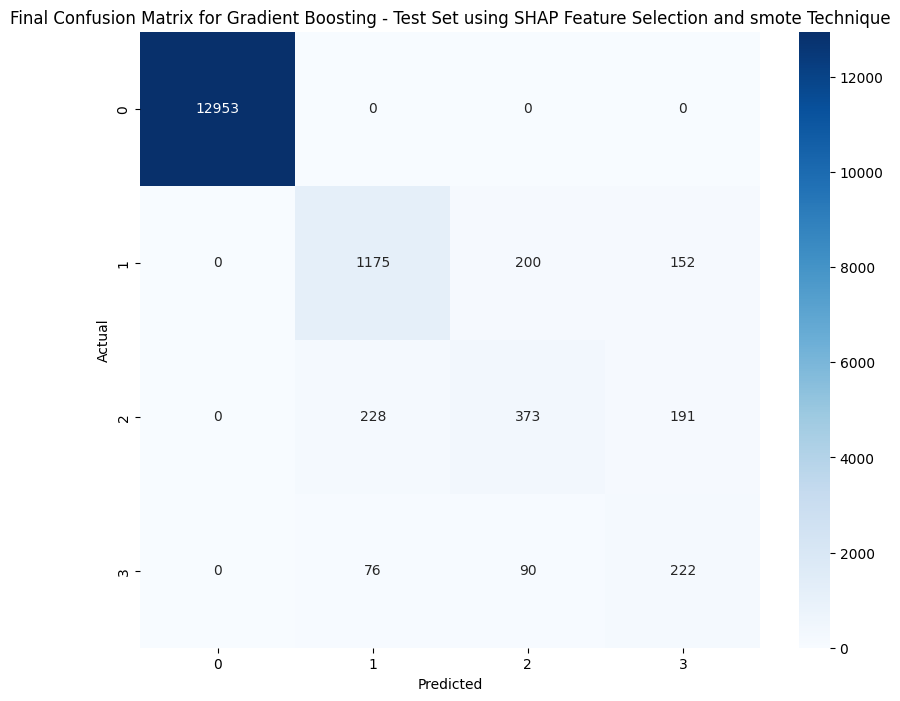

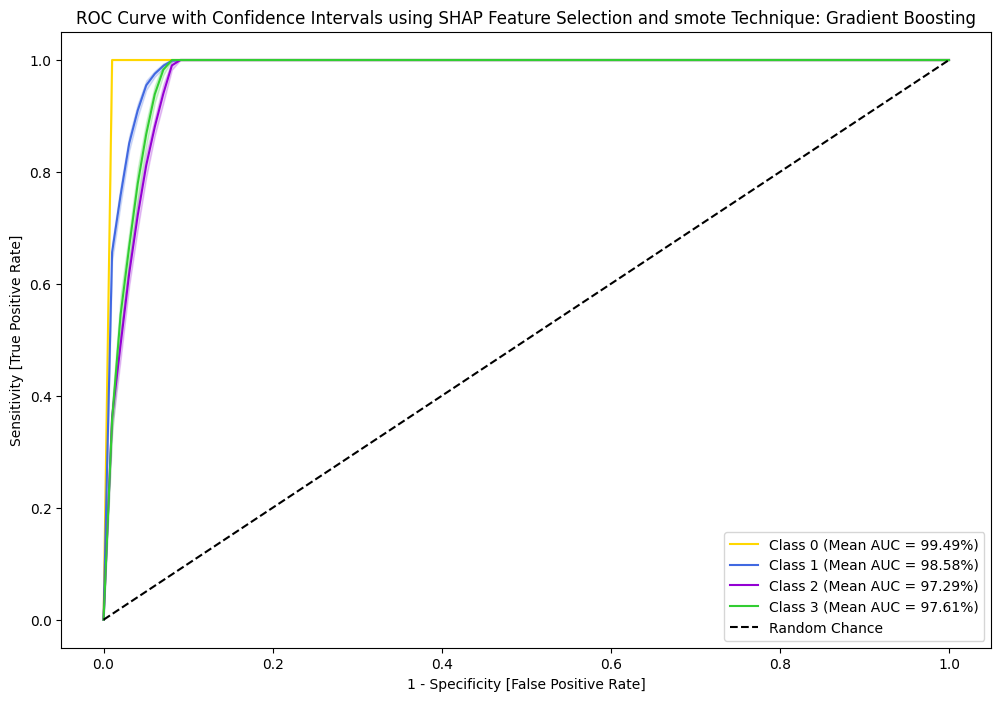


Gradient Boosting train and test predictions have been saved separately.


In [ ]:
param_grid_gb_shap = {
    'model__n_estimators': [50, 100, 200, 300],
    'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'model__max_depth': [3, 5, 7, 9],
    'model__subsample': [0.6, 0.7, 0.8, 1.0]
}


fold_results_gb_shap, best_model_gb_shap = nested_cv_model(
    GradientBoostingClassifier(random_state=42),  # Model for Gradient Boosting
    param_grid_gb_shap,                 # Parameter grid for Gradient Boosting
    'Gradient Boosting',            # Model name
    X_train_gb,                        # Training features
    y_train,                        # Training labels
    X_test_gb,                         # Test features
    y_test                          # Test labels
)
#665 mins

In [1]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, cross_val_score
import joblib
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

# Load data
train_resampled_set = pd.read_csv('train_set.csv')
test_set = pd.read_csv('test_set.csv')

# Define selected features for each model based on SHAP and SHAP analysis
selected_features_rf_SHAP = [
'Cost_claims_year',
'R_Claims_history',
'N_claims_history',
'Lapse',
'Age_Group_40-64',
'Distribution_channel',
'Age_Group_25-39',
'Seniority',
'Type_fuel_D',
'Type_fuel_P']

# Separate features and target for training and test sets
X_train_rf = train_resampled_set[selected_features_rf_SHAP]
y_train_resampled = train_resampled_set['N_claims_year']
X_test_rf = test_set[selected_features_rf_SHAP]
y_test = test_set['N_claims_year']

# Updated function with pipeline for smote
def nested_cv_model(model, param_grid, model_name, X_train, y_train, X_test, y_test):
    print(f"\nStarting Nested Cross-Validation for {model_name}...")

    # Define the pipeline with smote and the model
    pipeline = Pipeline([
        ('under', SMOTE(random_state=42)),
        ('model', model)
    ])

    # Inner cross-validation for hyperparameter tuning using the pipeline
    inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    search = RandomizedSearchCV(
        pipeline,
        param_distributions=param_grid,
        n_iter=10,
        scoring={'accuracy': 'accuracy', 'f1_weighted': 'f1_weighted'},
        refit='accuracy',
        cv=inner_cv,
        n_jobs=-1,
        random_state=42
    )

    # Outer cross-validation for model evaluation
    outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # Collect scores for each fold
    fold_results = []
    for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X_train, y_train), start=1):
        print(f"\nFold {fold}...")

        # Split data for this fold
        X_train_fold, X_test_fold = X_train.iloc[train_idx], X_train.iloc[test_idx]
        y_train_fold, y_test_fold = y_train.iloc[train_idx], y_train.iloc[test_idx]

        # Print class distribution in the original outer fold's training subset before resampling
        print("Original class distribution in training fold_shap_smote:", Counter(y_train_fold))

        # Inner cross-validation with hyperparameter tuning and resampling handled by the pipeline
        search.fit(X_train_fold, y_train_fold)

        # Evaluate on the outer test fold
        y_pred_fold = search.predict(X_test_fold)
        accuracy_fold = accuracy_score(y_test_fold, y_pred_fold)
        f1_fold = f1_score(y_test_fold, y_pred_fold, average='weighted')
        roc_auc_fold = roc_auc_score(pd.get_dummies(y_test_fold), pd.get_dummies(y_pred_fold), average='macro', multi_class='ovr')

        # Print fold results
        print(f"  Fold {fold} Accuracy_shap_smote: {accuracy_fold}")
        print(f"  Fold {fold} F1 Score_shap_smote: {f1_fold}")
        print(f"  Fold {fold} ROC AUC Score_shap_smote: {roc_auc_fold}")

        fold_results.append((fold, accuracy_fold, f1_fold, roc_auc_fold))


        # Plot confusion matrix for each fold
        conf_matrix = confusion_matrix(y_test_fold, y_pred_fold)
        plt.figure(figsize=(8, 6))
        sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
        plt.title(f"Confusion Matrix for {model_name} - Fold {fold} using SHAP Feature Selection and smote Technique")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.savefig(f"{model_name}_conf_matrix_fold_{fold}_SHAP_smote.png")
        plt.close()

    # Train the best model on the entire training set
    search.fit(X_train, y_train)
    best_model = search.best_estimator_

    # Predictions on training and test sets
    y_pred_train = best_model.predict(X_train)
    y_pred_test = best_model.predict(X_test)
    y_pred_probabilities = best_model.predict_proba(X_test)

    # Evaluation metrics on test set
    accuracy = accuracy_score(y_test, y_pred_test)
    f1 = f1_score(y_test, y_pred_test, average='weighted')
    roc_auc = roc_auc_score(pd.get_dummies(y_test), y_pred_probabilities, average='macro', multi_class='ovr')

    class_report = classification_report(y_test, y_pred_test)
    conf_matrix = confusion_matrix(y_test, y_pred_test)

    # Display results
    print(f"\n{model_name} Best Parameters: {search.best_params_} (SHAP_smote)")
    print(f"{model_name} Accuracy on Test Set: {accuracy} (SHAP_smote)")
    print(f"{model_name} F1 Score on Test Set: {f1} (SHAP_smote)")
    print(f"{model_name} ROC AUC Score on Test Set: {roc_auc} (SHAP_smote)")
    print(f"{model_name} Classification Report:\n{class_report} (SHAP_smote)")

    # Plot final confusion matrix for the test set
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
    plt.title(f"Final Confusion Matrix for {model_name} - Test Set using SHAP Feature Selection and smote Technique")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.savefig(f"{model_name}_final_conf_matrix_boru_smote.png")
    plt.show()

    # Updated ROC curve plotting with bootstrapped confidence intervals
    plt.figure(figsize=(12, 8))
    colors = ['gold', 'royalblue', 'darkviolet', 'limegreen']

    y_test_dummies = pd.get_dummies(y_test)
    bootstraps = 1000  # Number of bootstrap samples
    mean_fpr = np.linspace(0, 1, 100)

    for i, class_label in enumerate(np.unique(y_test)):
        tprs = []

        for _ in range(bootstraps):
            indices = np.random.randint(0, len(y_test), len(y_test))
            y_true_bootstrap = y_test_dummies.iloc[indices, i]
            y_pred_bootstrap = y_pred_probabilities[indices, i]
            fpr, tpr, _ = roc_curve(y_true_bootstrap, y_pred_bootstrap)
            tpr_interp = np.interp(mean_fpr, fpr, tpr)
            tpr_interp[0] = 0.0
            tprs.append(tpr_interp)

        mean_tpr = np.mean(tprs, axis=0)
        mean_tpr[-1] = 1.0
        mean_auc = auc(mean_fpr, mean_tpr)
        std_tpr = np.std(tprs, axis=0)

        plt.plot(mean_fpr, mean_tpr, color=colors[i % len(colors)], label=f'Class {class_label} (Mean AUC = {mean_auc:.2%})')
        plt.fill_between(mean_fpr, mean_tpr - std_tpr, mean_tpr + std_tpr, color=colors[i % len(colors)], alpha=0.2)

    plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
    plt.title(f"ROC Curve with Confidence Intervals using SHAP Feature Selection and smote Technique: {model_name}")
    plt.xlabel("1 - Specificity [False Positive Rate]")
    plt.ylabel("Sensitivity [True Positive Rate]")
    plt.legend(loc='lower right')
    plt.savefig(f"{model_name}_roc_curve_with_ci_(SHAP_smote).png")
    plt.show()

    # Export separate CSVs for train and test set predictions
    train_df = X_train.copy()
    train_df['y_true_train'] = y_train
    train_df['y_pred_train'] = y_pred_train

    # Save the original test set
    original_test_set = test_set.copy()  # Assuming `test_set` is the original test DataFrame
    original_test_set.to_csv(f"{model_name.lower().replace(' ', '_')}_original_test_set.csv", index=False)
    print(f"\nOriginal test set has been saved as '{model_name.lower().replace(' ', '_')}_original_test_set.csv'.")
    
    # Save the test set with predictions
    test_df = test_set[selected_features_rf_SHAP].copy()  # Use selected features
    if 'ID' in test_set.columns:  # Check if 'ID' column exists
        test_df['ID'] = test_set['ID']  # Add the ID column if present
    
    # Add true and predicted labels
    test_df['y_true_test'] = y_test
    test_df['y_pred_test'] = y_pred_test
    test_df.to_csv(f"{model_name.lower().replace(' ', '_')}_test_set_with_predictions.csv", index=False)
    print(f"Test set with predictions has been saved as '{model_name.lower().replace(' ', '_')}_test_set_with_predictions.csv'.")
    
    
    # Save the model
    joblib.dump(best_model, f"{model_name}_best_model_(SHAP_smote).joblib")

    return fold_results, best_model


Starting Nested Cross-Validation for Random Forest...

Fold 1...
Original class distribution in training fold_shap_smote: Counter({0: 41448, 1: 4888, 2: 2534, 3: 1240})


c:\Users\Prapatsorn\miniconda3\Lib\site-packages\sklearn\model_selection\_search.py:307: UserWarning: The total space of parameters 1 is smaller than n_iter=10. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


  Fold 1 Accuracy_shap_smote: 0.9363026819923371
  Fold 1 F1 Score_shap_smote: 0.9370911834469027
  Fold 1 ROC AUC Score_shap_smote: 0.8339815588204544

Fold 2...
Original class distribution in training fold_shap_smote: Counter({0: 41448, 1: 4888, 2: 2533, 3: 1241})


c:\Users\Prapatsorn\miniconda3\Lib\site-packages\sklearn\model_selection\_search.py:307: UserWarning: The total space of parameters 1 is smaller than n_iter=10. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


  Fold 2 Accuracy_shap_smote: 0.9373403575989783
  Fold 2 F1 Score_shap_smote: 0.9381370214380292
  Fold 2 ROC AUC Score_shap_smote: 0.8363105690763528

Fold 3...
Original class distribution in training fold_shap_smote: Counter({0: 41448, 1: 4888, 2: 2533, 3: 1241})


...

  Fold 4 Accuracy_shap_smote: 0.9381336313562705
  Fold 4 F1 Score_shap_smote: 0.9385524668489568
  Fold 4 ROC AUC Score_shap_smote: 0.835173383221954

Fold 5...
Original class distribution in training fold_shap_smote: Counter({0: 41448, 1: 4888, 2: 2534, 3: 1241})


c:\Users\Prapatsorn\miniconda3\Lib\site-packages\sklearn\model_selection\_search.py:307: UserWarning: The total space of parameters 1 is smaller than n_iter=10. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


  Fold 5 Accuracy_shap_smote: 0.9340624251616508
  Fold 5 F1 Score_shap_smote: 0.9352863193619069
  Fold 5 ROC AUC Score_shap_smote: 0.8289926183190374


c:\Users\Prapatsorn\miniconda3\Lib\site-packages\sklearn\model_selection\_search.py:307: UserWarning: The total space of parameters 1 is smaller than n_iter=10. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(



Random Forest Best Parameters: {'model__n_estimators': 300, 'model__min_samples_split': 5, 'model__min_samples_leaf': 4, 'model__max_depth': 20} (SHAP_smote)
Random Forest Accuracy on Test Set: 0.9372286079182631 (SHAP_smote)
Random Forest F1 Score on Test Set: 0.9380232040878046 (SHAP_smote)
Random Forest ROC AUC Score on Test Set: 0.9838414317346198 (SHAP_smote)
Random Forest Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     12953
           1       0.79      0.76      0.77      1527
           2       0.53      0.46      0.49       792
           3       0.36      0.51      0.42       388

    accuracy                           0.94     15660
   macro avg       0.67      0.68      0.67     15660
weighted avg       0.94      0.94      0.94     15660
 (SHAP_smote)


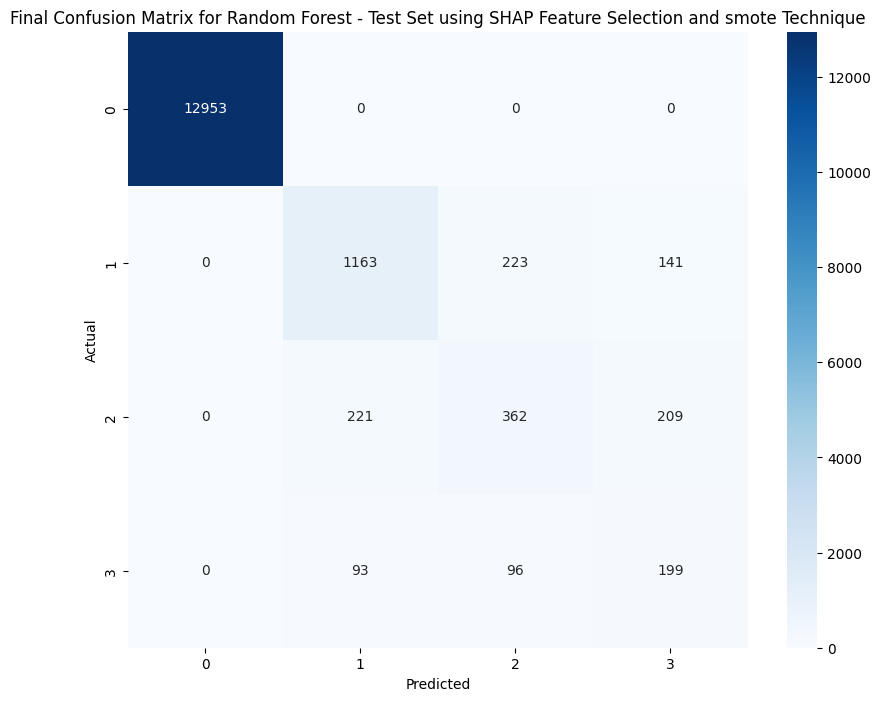

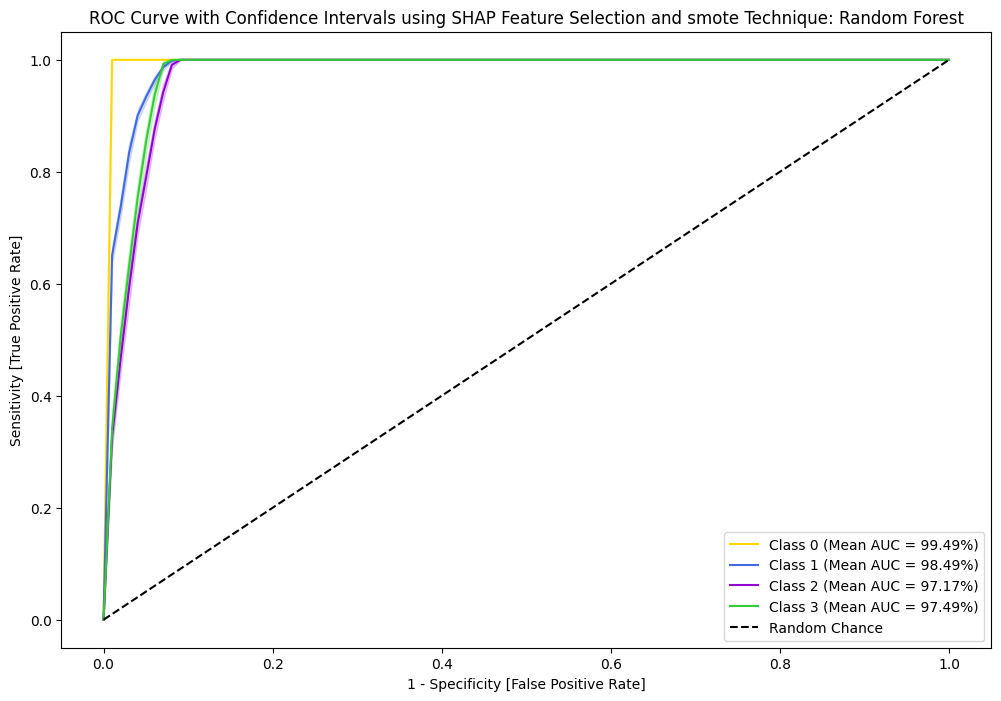


Original test set has been saved as 'random_forest_original_test_set.csv'.
Test set with predictions has been saved as 'random_forest_test_set_with_predictions.csv'.


In [5]:
import pandas as pd
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import auc, accuracy_score, f1_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from imblearn.pipeline import Pipeline  # Import the pipeline from imbalanced-learn
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import joblib
from imblearn.over_sampling import SMOTE  # Import SMOTE
param_grid_rf_shap = {
    'model__n_estimators': [300],
    'model__max_depth': [20],
    'model__min_samples_split': [5],
    'model__min_samples_leaf': [4]
}


fold_results_rf_shap, best_model_rf_shap = nested_cv_model(
    RandomForestClassifier(random_state=42),       # Model for Random Forest
    param_grid_rf_shap,                  # Parameter grid for Random Forest
    'Random Forest',                # Model name
    X_train_rf,                        # Training features
    y_train_resampled,                        # Training labels
    X_test_rf,                         # Test features
    y_test                          # Test labels
) #63 mins

In [ ]:

XGBoost = pd.read_csv("random_forest_test_set_with_predictions.csv")
XGBoost.describe()

In [6]:
rf = pd.read_csv("random_forest_test_set_with_predictions.csv")
rf.describe()

,Cost_claims_year,R_Claims_history,N_claims_history,Lapse,Age_Group_40-64,Distribution_channel,Age_Group_25-39,Seniority,Type_fuel_D,Type_fuel_P,ID,y_true_test,y_pred_test
count,15660.000000,15660.000000,15660.000000,15660.000000,15660.000000,15660.000000,15660.000000,15660.000000,15660.000000,15660.000000,15660.000000,15660.000000,15660.000000
mean,123.300324,0.404861,2.584100,0.219923,0.565453,0.462388,0.316475,6.544317,0.627969,0.372031,26837.250255,0.272989,0.286462
std,723.176505,0.670951,3.565757,0.453227,0.495713,0.498599,0.465115,6.235477,0.483362,0.483362,15268.728008,0.669554,0.708344
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,3.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,13767.500000,0.000000,0.000000
50%,0.000000,0.110000,1.000000,0.000000,1.000000,0.000000,0.000000,4.000000,1.000000,0.000000,26920.500000,0.000000,0.000000
75%,0.000000,0.560000,4.000000,0.000000,1.000000,1.000000,1.000000,8.000000,1.000000,1.000000,40105.750000,0.000000,0.000000
max,25071.950000,21.470000,49.000000,5.000000,1.000000,1.000000,1.000000,40.000000,1.000000,1.000000,53502.000000,3.000000,3.000000
